# Variable ice-rock coupling near the grounding zone of Totten Glacier, East Antarctica, inferred from repeating stick-slip icequakes

**Jared C. Magyar, 2026**

The following notebook produces the figures presented in the associated manuscript. Note that this loads results from the scripts enclosed in the Github repository, which must be run first to complete reproduce the visualisations. Some of the figures require other products such as Bedmap3 or grounding line shapefiles. The local paths for these should be changed and any alternative product can be used in the visualisation by interpolating onto the inversion grid shown. This includes the effective pressure distribution used here, which can be replaced with any other model output or spatial dataset.

In [1]:
import numpy as np
import xarray as xr
import netCDF4 as nc
from obspy.core.inventory import inventory
from cryoquake import data_objects as do
from cryoquake import spatial_analysis as sa
from cryoquake import event_calculation as ec
from cryoquake import moment_magnitude as mm
from obspy.core import UTCDateTime, read, Stream, Trace
import matplotlib.pyplot as plt
import obspy
from obspy.signal.filter import envelope
import multiprocessing as mp
import matplotlib.colors as mcolors
from matplotlib.colors import LinearSegmentedColormap, Normalize
import tqdm
import pandas as pd
import os
from matplotlib.dates import DateFormatter, HourLocator, DayLocator
from obspy.imaging.util import _set_xaxis_obspy_dates
from matplotlib import rcParams
import plotly_resampler
import plotly.graph_objects as go
from plotly_resampler import FigureResampler, FigureWidgetResampler
from obspy.geodetics import degrees2kilometers, kilometers2degrees
from matplotlib.dates import DateFormatter, DayLocator, HourLocator
from scipy.signal import hilbert
from multitaper.mtspec import MTSine, MTSpec
from scipy.optimize import minimize
from scipy.signal.windows import get_window
from scipy.optimize import least_squares
from uncertainties import ufloat
from uncertainties.umath import cos, log10
from obspy.realtime.signal import kurtosis
import plotly.graph_objects as go
from plotly_resampler import FigureResampler, FigureWidgetResampler
from matplotlib_scalebar.scalebar import ScaleBar
from scipy.special import kl_div, rel_entr
from scipy.stats import gaussian_kde, chi2, norm
from pathlib import Path
from matplotlib.patches import Rectangle
import matplotlib.path as mpath


import pyproj
proj_wgs84 = pyproj.Proj(init="epsg:4326")
proj_epsg3031 = pyproj.Proj(init="epsg:3031")

import cartopy.crs as ccrs
import cartopy.io.shapereader as shpreader
import cartopy as ctp

from shapely.ops import transform as shp_transform


wgs84 = ccrs.PlateCarree()
stereo = ccrs.epsg(3031)
map_proj = ccrs.SouthPolarStereo()



from matplotlib import rc
import matplotlib.font_manager as fm
#rc('text', usetex=True)

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.sans-serif'] = 'Computer Modern'
#rc('text', usetex=True)
from matplotlib import rc
rc('font', size=8)
#rc('font', **{'family': 'sans-serif', 'sans-serif': ['Arial']})

/Users/jmagyar/opt/miniconda3/envs/seismo_analysis/lib/python3.11/site-packages/pyproj/crs/crs.py:141: FutureWarning: '+init=<authority>:<code>' syntax is deprecated. '<authority>:<code>' is the preferred initialization method. When making the change, be mindful of axis order changes: https://pyproj4.github.io/pyproj/stable/gotchas.html#axis-order-changes-in-proj-6
  in_crs_string = _prepare_from_proj_string(in_crs_string)
/Users/jmagyar/opt/miniconda3/envs/seismo_analysis/lib/python3.11/site-packages/pyproj/crs/crs.py:141: FutureWarning: '+init=<authority>:<code>' syntax is deprecated. '<authority>:<code>' is the preferred initialization method. When making the change, be mindful of axis order changes: https://pyproj4.github.io/pyproj/stable/gotchas.html#axis-order-changes-in-proj-6
  in_crs_string = _prepare_from_proj_string(in_crs_string)


In [2]:
def cmap_bedmachine():
  colors = [
    (17/256, 29/256, 57/256), # Dark blue
    (59/256, 89/256, 130/256), # Navy blue
    (102/256, 172/256, 222/256), # Baby blue
    (255/256, 255/256, 255/256), # White
    (58/256, 97/256, 39/256), # Dark green
    (93/256, 156/256, 63/256), # Green
    (195/256, 180/256, 79/256), # Yellow
    (107/256, 82/256, 0), # Brown
    (52/256 ,37/256, 0) # Dark brown
  ]
  values = [-3000, -1000, -500, 0, 1, 500, 1000, 1500, 3000]
  norm = plt.Normalize(min(values), max(values))
  cmapping = list(zip(norm(values), colors))
  custom_cmap = LinearSegmentedColormap.from_list(name = 'BedMachine', colors = cmapping)
  return custom_cmap


vel_cmap = LinearSegmentedColormap.from_list('velocity', (
    # Edit this gradient at https://eltos.github.io/gradient/#velocity=0:FFFFFF-10:4EACE0-20:A6A8A6-40:DBCC65-70:EC1616-100:1B0001
    (0.000, (1.000, 1.000, 1.000)),
    (0.100, (0.306, 0.675, 0.878)),
    (0.200, (0.651, 0.659, 0.651)),
    (0.400, (0.859, 0.800, 0.396)),
    (0.700, (0.925, 0.086, 0.086)),
    (1.000, (0.106, 0.000, 0.004))))

In [3]:
t1 = UTCDateTime(2018,12,24)
t2 = UTCDateTime(2019,1,30)

chunk = do.SeismicChunk(t1,t2)

root = Path.cwd()
w_path = root / "stacked_waveforms"
raw_path = root / "waveforms"
s_path = root / "stations"
c_path = root / "catalogues"
m_path = root / "misfit"
o_path = root / "outputs"
a_path = root / "arrivals"

for path in [o_path]:
    if not os.path.exists(path):
        os.mkdir(path)


inv_files = os.listdir(s_path)

inv = inventory.Inventory()

for file in inv_files:
    temp_path = os.path.join(s_path,file)
    inv += inventory.read_inventory(temp_path,level='response',format='STATIONXML')

inv = inv.select(station='TI?A',channel='CH?')

temp_cat = do.EventCatalogue(t1,t2,os.path.join(c_path,'network'),templates=True)

moment_mags = chunk.load_csv(os.path.join(c_path,'network'),'moment_magnitude')
temp_cat.attributes['Mw'] = moment_mags['Mw']
groups = temp_cat.group_split()

In [4]:
network_lst = []
station_lst = []
lat_lst = []
lon_lst = []
for network in inv:
    for station in network:
        network_lst.append(network.code)
        station_lst.append(station.code)
        lat_lst.append(station.latitude)
        lon_lst.append(station.longitude)

station_df = pd.DataFrame({'Network':network_lst,'Station':station_lst,'Latitude':lat_lst,'Longitude':lon_lst})
centre = (station_df['Longitude'].mean(),station_df['Latitude'].mean())

tide_lat = -67.25
tide_lon = 114.5

casey_lat = -66.2821
casey_lon = 110.5285

In [5]:
directory = '/Users/jmagyar/Documents/MappingProducts/' #!this needs to be a path to the location of these mapping products
bedmachine_file = directory + 'BedMachineAntarctica-v3.nc'
groundingline_file = directory + 'GroundingLine_Antarctica_v02.shp'
groundingline_file2 = directory + 'InSAR_GL_Antarctica_v02.shp'
grounding_zone = directory + 'Antarctic_GZ_2018_v01.0.shp'
coastline_file = directory + 'Coastline_Antarctica_v02.shp'
ice_velocity_file = directory + 'antarctica_ice_velocity_450m_v2.nc'
bedmap3_file = directory + 'bedmap3.nc'
bedmap3 = xr.open_dataset(bedmap3_file, engine="netcdf4")

hydrology_file = directory + 'hydrology_outputs_ll.nc'

hydrology_data = xr.open_dataset(hydrology_file, engine="netcdf4")
vel_data = xr.open_dataset(ice_velocity_file, engine="netcdf4")

In [6]:
np.diff(vel_data.x.values)

array([450., 450., 450., ..., 450., 450., 450.])

In [7]:
grounding_zone_data = shpreader.Reader(grounding_zone)

groundingline_file2 = directory + 'InSAR_GL_Antarctica_v02.shp'
groundingline_data2 = shpreader.Reader(groundingline_file2)
coastline_data = shpreader.Reader(coastline_file)


up = []
dn = []
isl = []
for record in grounding_zone_data.records():
    if (record.attributes['Boundary'] == 'Up') & (record.attributes['Type'] == 'Ice Sheet'):
        up.append(record)
    if (record.attributes['Boundary'] == 'Dn') & (record.attributes['Type'] == 'Ice Sheet'):
        dn.append(record)
    if ((record.attributes['Type'] == 'Island') | (record.attributes['Type'] == 'EIR')):
        isl.append(record)

from pyproj import Transformer

to_wgs84 = Transformer.from_crs("EPSG:3031", "EPSG:4326", always_xy=True).transform
to_epsg3031 = Transformer.from_crs("EPSG:4326","EPSG:3031", always_xy=True).transform

def reproject_geom(geom):
    """Reproject a shapely geometry from EPSG:3031 to EPSG:4326."""
    return shp_transform(to_wgs84, geom)

def reverse_reproject_geom(geom):
    """Reproject a shapely geometry from EPSG:3031 to EPSG:4326."""
    return shp_transform(to_epsg3031, geom)

up_ll = [reproject_geom(rec.geometry) for rec in up]
dn_ll = [reproject_geom(rec.geometry) for rec in dn]
isl_ll = [reproject_geom(rec.geometry) for rec in isl]

up_xy = [rec.geometry for rec in up]
sta_xy, D, sta_lst = sa.EPSGStations(inv)

/Users/jmagyar/opt/miniconda3/envs/seismo_analysis/lib/python3.11/site-packages/pyproj/crs/crs.py:141: FutureWarning: '+init=<authority>:<code>' syntax is deprecated. '<authority>:<code>' is the preferred initialization method. When making the change, be mindful of axis order changes: https://pyproj4.github.io/pyproj/stable/gotchas.html#axis-order-changes-in-proj-6
  in_crs_string = _prepare_from_proj_string(in_crs_string)
/Users/jmagyar/opt/miniconda3/envs/seismo_analysis/lib/python3.11/site-packages/pyproj/crs/crs.py:141: FutureWarning: '+init=<authority>:<code>' syntax is deprecated. '<authority>:<code>' is the preferred initialization method. When making the change, be mindful of axis order changes: https://pyproj4.github.io/pyproj/stable/gotchas.html#axis-order-changes-in-proj-6
  in_crs_string = _prepare_from_proj_string(in_crs_string)
/Users/jmagyar/Documents/icequakecode/cryoquake/src/cryoquake/spatial_analysis.py:641: FutureWarning: This function is deprecated. See: https://py

In [8]:
x = bedmap3.variables["x"][:]   # 1D array of x coords (EPSG:3031)
y = bedmap3.variables["y"][:]   # 1D array of y coords
bed = bedmap3.variables["bed_topography"][:]

# --- Define lat/lon bounding box ---
lon_min, lon_max = 100, 130
lat_min, lat_max = -74, -60

# --- Set up transformer ---
transformer = Transformer.from_crs("EPSG:4326", "EPSG:3031", always_xy=True)

# Convert corners
x_min, y_min = transformer.transform(lon_min, lat_min)
x_max, y_max = transformer.transform(lon_max, lat_max)

# Ensure ordering (since polar projections can flip)
xmin, xmax = sorted([x_min, x_max])
ymin, ymax = sorted([y_min, y_max])

# --- Find index ranges ---
ix = np.where((x >= xmin) & (x <= xmax))[0]
iy = np.where((y >= ymin) & (y <= ymax))[0]

# Crop data
bed_crop = bed[np.min(iy):np.max(iy)+1, np.min(ix):np.max(ix)+1]

# Corresponding coordinates
x_crop = x[np.min(ix):np.max(ix)+1]
y_crop = y[np.min(iy):np.max(iy)+1]

In [9]:
#make a dataframe for the map grid
map_grid = xr.Dataset(coords=dict(x=("x", x_crop),y=("y", y_crop)))
bedmap_interp = bedmap3.interp_like(map_grid)
ep_interp = hydrology_data.interp_like(map_grid)
vel_interp = vel_data.interp_like(map_grid)
map_grid = map_grid.assign(dict(bed_topography = bedmap_interp.bed_topography,effective_pressure=ep_interp.effective_pressure,sheet_thickness=ep_interp.sheet_thickness,bed_uncertainty=bedmap_interp.bed_uncertainty,velX=vel_interp.VX,velY=vel_interp.VY))

/Users/jmagyar/opt/miniconda3/envs/seismo_analysis/lib/python3.11/site-packages/shapely/predicates.py:798: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)
/Users/jmagyar/opt/miniconda3/envs/seismo_analysis/lib/python3.11/site-packages/shapely/set_operations.py:133: RuntimeWarning: invalid value encountered in intersection
  return lib.intersection(a, b, **kwargs)
/Users/jmagyar/opt/miniconda3/envs/seismo_analysis/lib/python3.11/site-packages/shapely/constructive.py:181: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(
/Users/jmagyar/opt/miniconda3/envs/seismo_analysis/lib/python3.11/site-packages/shapely/constructive.py:181: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(
/Users/jmagyar/opt/miniconda3/envs/seismo_analysis/lib/python3.11/site-packages/shapely/constructive.py:181: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(
/Users/jmagyar/opt/miniconda3/envs/seism

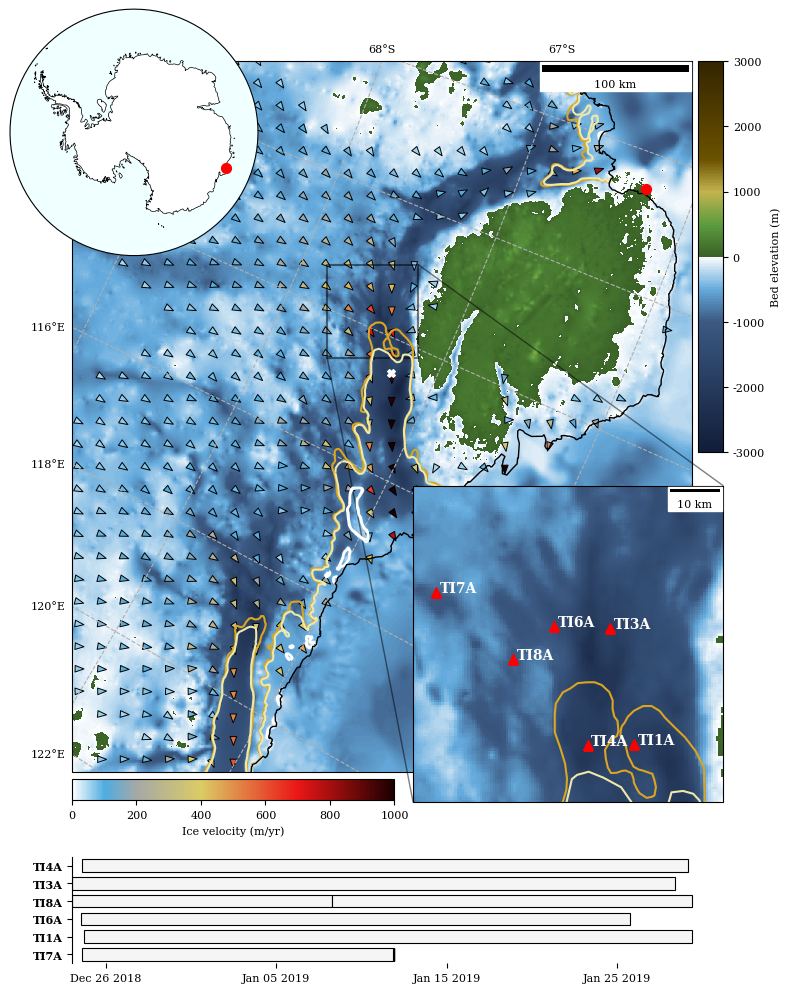

/Users/jmagyar/opt/miniconda3/envs/seismo_analysis/lib/python3.11/site-packages/shapely/constructive.py:181: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(
/Users/jmagyar/opt/miniconda3/envs/seismo_analysis/lib/python3.11/site-packages/shapely/constructive.py:181: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(
/Users/jmagyar/opt/miniconda3/envs/seismo_analysis/lib/python3.11/site-packages/shapely/predicates.py:798: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)
/Users/jmagyar/opt/miniconda3/envs/seismo_analysis/lib/python3.11/site-packages/shapely/constructive.py:181: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(
/Users/jmagyar/opt/miniconda3/envs/seismo_analysis/lib/python3.11/site-packages/shapely/constructive.py:181: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(
/Users/jmagyar/opt/miniconda3/envs/seismo_analysis/lib/python3.11/sit

In [10]:
wgs84 = ccrs.PlateCarree()
stereo = ccrs.epsg(3031)

# --- Reproject grounding line records ---
up_ll = [reproject_geom(rec.geometry) for rec in up]
dn_ll = [reproject_geom(rec.geometry) for rec in dn]
isl_ll = [reproject_geom(rec.geometry) for rec in isl]

# --- Reproject coastline if needed ---
coast_ll = [reproject_geom(geom) for geom in coastline_data.geometries()]

# --- Figure ---
fig = plt.figure(figsize=(8, 10))
ax = fig.add_subplot(111, projection=ccrs.SouthPolarStereo())



ax.set_extent([110.5, 119.5, -68.4, -66], crs = wgs84) # Define map extent in axis via [minlon, maxlon, minlat, maxlat]

#ax_spare = fig.add_subplot(122, projection = ccrs.SouthPolarStereo()) # Uncomment this if you want to see how Obspy handles multiple subplots!

# Add BedMachine & MEaSUREs data to map & style (as before)
#bedmachine_data = nc.Dataset(bedmachine_file)
#pcm = ax.pcolormesh(bedmachine_data.variables['x'][::10], bedmachine_data.variables['y'][::10], bedmachine_data.variables['bed'][::10,::10],
                    #cmap = cmap_bedmachine(), transform = ccrs.epsg(3031), vmin = -3000, vmax = 3000) # N.B. Rerun custom colormaps block above

# Raster (stays in EPSG:3031)
pcm = ax.pcolormesh(map_grid.x, map_grid.y, map_grid.bed_topography,cmap=cmap_bedmachine(),transform=stereo,vmin=-3000, vmax=3000,zorder=1,rasterized=True)

skip = 30

X, Y = np.meshgrid(x_crop[::skip], y_crop[::skip])
XYT = ax.projection.transform_points(stereo,X,Y)
X1 = XYT[:,:,0]
Y1 = XYT[:,:,1]

U = map_grid.velX.values[::skip, ::skip]
V = map_grid.velY.values[::skip, ::skip]

mag = np.sqrt(U**2 + V**2)

Uhat = U / mag
Vhat = V / mag

Uhat[mag <= 50] = np.nan
Vhat[mag <= 50] = np.nan


vel_q = ax.quiver(X1,Y1,Uhat,Vhat,mag,cmap=vel_cmap,scale=70,headwidth=6,headlength=8,headaxislength=8,edgecolor='black',linewidth=0.7,norm=Normalize(vmin=0,vmax=1000))


# Grounding lines (now in lon/lat)
ax.add_geometries(up_ll, crs=wgs84, facecolor="none", edgecolor="goldenrod", linewidth=1.5, zorder=5)
ax.add_geometries(dn_ll, crs=wgs84, facecolor="none", edgecolor="palegoldenrod", linewidth=1.5, zorder=5)
ax.add_geometries(isl_ll, crs=wgs84, facecolor="none", edgecolor="white", linewidth=1.5, zorder=5)

# Coastline
ax.add_geometries(coast_ll, crs=wgs84, facecolor="none", edgecolor="black", linewidth=1, zorder=5)

# Stations (already lon/lat)
#station_df.plot.scatter(ax=ax, x="Longitude", y="Latitude",transform=wgs84, c="red", marker="^", s=30, zorder=20)


#ax.gridlines(draw_labels = True, linestyle = '--')

gl = ax.gridlines(crs=wgs84, draw_labels = {'top':'y','left':'x'}, linestyle = '--',x_inline=False,y_inline=False,rotate_labels=False)


#station_df.plot.scatter(ax = ax, x = 'Longitude', y = 'Latitude', transform = wgs84, c = 'red', marker = '^', s = 30,zorder=10)

ant_ax = ax.inset_axes(bounds = [-0.1, 0.7, 0.4, 0.4], transform = ax.transAxes, projection = map_proj)
ant_ax.set_extent([0,360,-90,-60],crs=wgs84)
ant_ax.coastlines(lw=0.5)
ant_ax.add_feature(ctp.feature.OCEAN,facecolor='azure')
#ant_ax.add_geometries(coastline_data.geometries(), ccrs.epsg(3031), facecolor='white', edgecolor = 'black',lw=0.3)

theta = np.linspace(0, 2*np.pi, 100)
center, radius = [0.5, 0.5], 0.5
verts = np.vstack([np.sin(theta), np.cos(theta)]).T
circle = mpath.Path(verts*radius + center)
ant_ax.set_boundary(circle, transform = ant_ax.transAxes)

#ant_ax.scatter(centre[0],centre[1],s=30,marker='o',color='red',transform=wgs84,zorder=5)
ant_ax.scatter(casey_lon,casey_lat,s=50,marker='o',color='red',transform=wgs84,zorder=10)

scalebar = ScaleBar(0.001, "km", fixed_value=100)
ax.add_artist(scalebar)

inset_ax1 = ax.inset_axes(bounds = [1.01, 0.45, 0.04, 0.55], transform = ax.transAxes)
clb = fig.colorbar(pcm, cax = inset_ax1)
clb.set_label('Bed elevation (m)')
inset_ax1.set_yticks([-3000,-2000,-1000,0,1000,2000,3000],['-3000','-2000','-1000','0','1000','2000','3000'])

inset_ax2 = ax.inset_axes(bounds = [0.55, -0.07, 0.5, 0.5], transform = ax.transAxes, projection = map_proj)
inset_ax2.set_extent([113.2, 114.3, -67.7, -67.3], crs = wgs84)
ax.indicate_inset_zoom(inset_ax2, edgecolor = 'black',linewidth=1.5) # indicate on main axes the inset axes
inset_ax2.pcolormesh(x_crop, y_crop, bed_crop,cmap=cmap_bedmachine(),transform=stereo,vmin=-3000, vmax=3000,zorder=1,rasterized=True) # N.B. Rerun custom colormaps block above
#inset_ax2.add_geometries(groundingline_data2.geometries(), wgs84, facecolor = 'none', edgecolor = 'yellow', linewidth = 1)
#inset_ax2.add_geometries(groundingline_data.geometries(), ccrs.epsg(3031), facecolor = 'none', edgecolor = 'white', linewidth = 1,linestyle='--')

# Grounding lines (now in lon/lat)
inset_ax2.add_geometries(up_ll, crs=wgs84, facecolor="none", edgecolor="goldenrod", linewidth=1.5, zorder=10)
inset_ax2.add_geometries(dn_ll, crs=wgs84, facecolor="none", edgecolor="palegoldenrod", linewidth=1.5, zorder=10)
inset_ax2.add_geometries(isl_ll, crs=wgs84, facecolor="none", edgecolor="white", linewidth=1.5, zorder=10)

inset_ax2.add_geometries(coast_ll, crs=wgs84, facecolor="none", edgecolor="black", linewidth=1, zorder=5)


inset_ax3 = ax.inset_axes(bounds = [0, -0.04, 0.52, 0.03], transform = ax.transAxes)
clb = fig.colorbar(plt.cm.ScalarMappable(plt.Normalize(0,1000),cmap=vel_cmap), cax = inset_ax3,orientation='horizontal')
inset_ax3.set_xlabel('Ice velocity (m/yr)')
inset_ax3.set_xticks([0,200,400,600,800,1000],['0','200','400','600','800','1000'])

#inset_ax2.add_geometries(grounding_zone_data.geometries(), ccrs.epsg(3031), facecolor = 'none', edgecolor = 'yellow', linewidth = 1.2)


station_df.plot.scatter(ax = inset_ax2, x = 'Longitude', y = 'Latitude', transform = wgs84, c = 'red', marker = '^', s = 50,zorder=10)


for i, row in station_df.iterrows():
    station_ll = map_proj.transform_point(row['Longitude'],row['Latitude'],wgs84)
    #inset_ax2.annotate(fr"\textbf{{{row['Station']}}}",station_ll,c='white',zorder=15)
    inset_ax2.annotate(row['Station'],station_ll,c='white',zorder=15,weight='bold',fontsize=10,xytext=(0.25,0), textcoords='offset fontsize')

tide_xy = map_proj.transform_point(tide_lon,tide_lat,wgs84)
casey_xy = map_proj.transform_point(casey_lon,casey_lat,wgs84)

ax.scatter(tide_xy[0],tide_xy[1],color='white',marker='X',s=30,zorder=10)
ax.scatter(casey_xy[0],casey_xy[1],color='red',marker='o',s=50,zorder=10)


scalebar2 = ScaleBar(0.001, "km", fixed_value=10)
inset_ax2.add_artist(scalebar2)

avail = pd.read_csv('totten_stream_availability.csv')

avail_ax = ax.inset_axes(bounds = [0, -0.27, 1.05, 0.15], transform = ax.transAxes)

i = 0
labels = []
coords = []

rows = []

for i, row in station_df.iterrows():
   

    subset = avail[(avail['Station']==row['Station']) & (avail['Channel']=='CHZ')]
    
    starts = subset['Start'].to_numpy()
    ends = subset['End'].to_numpy()

    short_start = []
    short_end = []
    short_start.append(starts[0])

    for i, start in enumerate(starts[1:]):
        if start != ends[i]:
            short_start.append(start)
            short_end.append(ends[i])

    short_end.append(ends[-1])

    for i in range(len(short_start)):
        rows.append({'Station':row['Station'],'Start':short_start[i],'End':short_end[i]})

df = pd.DataFrame(data=rows)

for i, row in station_df.iterrows():
    subset = df[(df['Station']==row['Station'])]
    start = pd.to_datetime(subset['Start'])# + pd.Timedelta(hours=chunk.time_offset)
    end = pd.to_datetime(subset['End']) #+ pd.Timedelta(hours=chunk.time_offset)
    duration = end - start

    color='whitesmoke'
        
    avail_ax.barh(-i,duration,height=0.7,left=start,facecolor=color,edgecolor='black',lw=0.8)
    coords.append(-i)
    #labels.append(fr"\textbf{{{row['Station']}}}")
    labels.append(row['Station'])

avail_ax.set_yticks(coords)
avail_ax.set_yticklabels(labels,weight='bold')
avail_ax.spines['right'].set_visible(False)
#avail_ax.spines['left'].set_visible(False)
avail_ax.spines['top'].set_visible(False)
avail_ax.spines['bottom'].set_visible(False)

myFmt = DateFormatter("%b %d %Y",usetex=False)
avail_ax.xaxis.set_major_formatter(myFmt)
avail_ax.xaxis.set_major_locator(DayLocator(interval=10))

#_set_xaxis_obspy_dates(avail_ax)
avail_ax.set_ylim(-5.5,0.5)
#avail_ax.set_ylabel('Data availability')

plt.show();

fig.savefig(os.path.join(o_path,'Fig1_totten_map.pdf'),bbox_inches='tight',dpi=400)

## Event Catalogue

The STA/LTA event catalogue can be produced using the script `totten_analysis.py'. This is loaded here from the .csv files, and the attributes and temporal distribution of the events detected plotted.

In [11]:
network_cat = do.EventCatalogue(t1,t2,os.path.join(c_path,'network'))
print('Network Catalogue Events:',network_cat.N)

Network Catalogue Events: 437


In [12]:
#tidal cycle for network catalogue.
tides = np.load('totten_tides.npz')
dt = tides['dt']
tide = tides['tide']

tide = tide[dt <= (t2 - t1)]
dt = dt[dt <= (t2 - t1)]

analytic_signal = hilbert(tide)
amplitude_envelope = np.abs(analytic_signal)
instantaneous_phase = np.unwrap(np.angle(analytic_signal))
tidal_phase = (instantaneous_phase % (2*np.pi) - np.pi) * 180/np.pi

tidal_phase += 180
tidal_phase[tidal_phase > 180] -= 360

In [13]:
for event_id, row in network_cat.attributes.iterrows():
    time = UTCDateTime(network_cat.events.at[event_id,'ref_time'])
    network_cat.attributes.at[event_id,'time'] = time.matplotlib_date
    network_cat.attributes.at[event_id,'diurnal'] = UTCDateTime(2018,1,1,time.hour,time.minute,time.second).matplotlib_date
    delta_t = time - t1
    network_cat.attributes.at[event_id,'phase'] = np.interp(delta_t,dt,tidal_phase)
    network_cat.attributes.at[event_id,'height'] = np.interp(delta_t,dt,tide)

fine_bins = np.array([time.matplotlib_date for time in np.mgrid[chunk.starttime:chunk.endtime+1:6*60*60]])
stalta_hist, _ = np.histogram(network_cat.attributes['time'],bins=fine_bins)

In [14]:
network_attributes = chunk.load_csv(os.path.join(c_path,'network'),'waveform_attributes')
network_attributes.dropna(inplace=True)

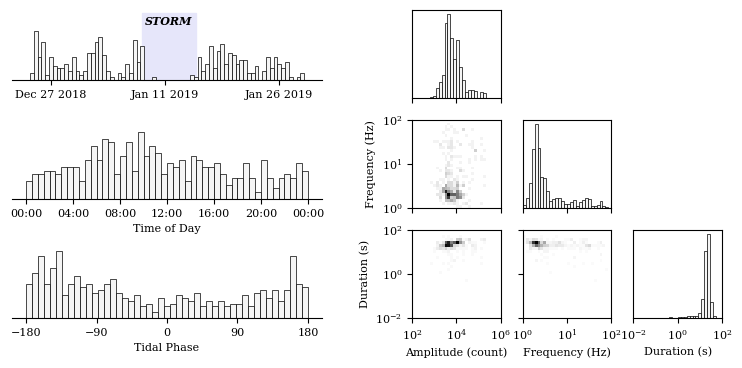

In [15]:
master_fig = plt.figure(figsize=(8,4))

storm_start = UTCDateTime(2019,1,8).matplotlib_date
storm_end = UTCDateTime(2019,1,15).matplotlib_date

dist_fig, att_fig = master_fig.subfigures(ncols=2)

dist_gs = dist_fig.add_gridspec(nrows=3,hspace=0.7)

det_ax = dist_fig.add_subplot(dist_gs[0])
diurnal_ax = dist_fig.add_subplot(dist_gs[1])
tide_ax = dist_fig.add_subplot(dist_gs[2])

fine_bins = np.array([time.matplotlib_date for time in np.mgrid[chunk.starttime:chunk.endtime+1:12*60*60]])
stalta_hist, _ = np.histogram(network_cat.attributes['time'],bins=fine_bins)


det_ax.bar(fine_bins[:-1],stalta_hist,width=np.diff(fine_bins),facecolor='whitesmoke',edgecolor='black',lw=0.5)

det_ax.spines['top'].set_visible(False)
det_ax.spines['left'].set_visible(False)
det_ax.spines['right'].set_visible(False)
det_ax.set_yticks([])

myFmt = DateFormatter("%b %d %Y",usetex=False)
det_ax.xaxis.set_major_formatter(myFmt)
det_ax.xaxis.set_major_locator(DayLocator(interval=15))


day_bins = np.array([time.matplotlib_date for time in np.mgrid[UTCDateTime(2018,1,1):UTCDateTime(2018,1,2)+1:30*60]])
temp_hist, _ = np.histogram(network_cat.attributes['diurnal'],bins=day_bins)

diurnal_ax.bar(day_bins[:-1],temp_hist,width=np.diff(day_bins),align='edge',facecolor='whitesmoke',edgecolor='black',lw=0.5)


myFmt = DateFormatter("%H:%M")
diurnal_ax.xaxis.set_major_formatter(myFmt)
diurnal_ax.xaxis.set_major_locator(HourLocator(interval=4))
diurnal_ax.spines['top'].set_visible(False)
diurnal_ax.spines['left'].set_visible(False)
diurnal_ax.spines['right'].set_visible(False)
diurnal_ax.set_yticks([])
diurnal_ax.set_xlabel('Time of Day')

tide_bins = np.linspace(-180,180,48)
temp_hist, _ = np.histogram(network_cat.attributes['phase'],bins=tide_bins)

tide_ax.bar(tide_bins[:-1],temp_hist,width=np.diff(tide_bins),align='edge',facecolor='whitesmoke',edgecolor='black',lw=0.5)

tide_ax.spines['top'].set_visible(False)
tide_ax.spines['left'].set_visible(False)
tide_ax.spines['right'].set_visible(False)
tide_ax.set_yticks([])
tide_ax.set_xlabel('Tidal Phase')
tide_ax.set_xticks([-180,-90,0,90,180]);


#ATTRIBUTES SUBFIGURE
grid_spec = att_fig.add_gridspec(ncols=3,nrows=3,width_ratios=[1,1,1],height_ratios=[1,1,1],hspace=0.25,wspace=0.25)

amp_hist = att_fig.add_subplot(grid_spec[0,0])
freq_hist = att_fig.add_subplot(grid_spec[1,1])
dur_hist = att_fig.add_subplot(grid_spec[2,2])

amp_hist.set_xscale('log')
freq_hist.set_xscale('log')
dur_hist.set_xscale('log')

amp_freq = att_fig.add_subplot(grid_spec[1,0],sharex=amp_hist)
amp_dur = att_fig.add_subplot(grid_spec[2,0],sharex=amp_hist)
freq_dur = att_fig.add_subplot(grid_spec[2,1],sharex=freq_hist)

amp_freq.set_xscale('log')
amp_freq.set_yscale('log')
amp_dur.set_xscale('log')
amp_dur.set_yscale('log')
freq_dur.set_yscale('log')
freq_dur.set_xscale('log')


amps = network_attributes['amplitude'].to_numpy()
freqs = network_attributes['mean_freq'].to_numpy()
durs = network_attributes['duration'].to_numpy()

num_bins = 30

amp_bins = np.geomspace(1e2,1e6,num_bins+1)
freq_bins = np.geomspace(1e0,1e2,num_bins+1)
dur_bins = np.geomspace(1e-2,1e2,num_bins+1)

amp_count, _ = np.histogram(amps,bins=amp_bins)
freq_count, _ = np.histogram(freqs,bins=freq_bins)
dur_count, _ = np.histogram(durs,bins=dur_bins)

amp_freq_count, _, _ = np.histogram2d(amps,freqs,bins=(amp_bins,freq_bins))
amp_dur_count, _, _ = np.histogram2d(amps,durs,bins=(amp_bins,dur_bins))
freq_dur_count, _, _ = np.histogram2d(freqs,durs,bins=(freq_bins,dur_bins))

freq_hist.bar(freq_bins[:-1],height=freq_count,width=np.diff(freq_bins),align='edge',facecolor='whitesmoke',edgecolor='black',lw=0.5)
freq_hist.set_yticks([])

amp_hist.bar(amp_bins[:-1],height=amp_count,width=np.diff(amp_bins),align='edge',facecolor='whitesmoke',edgecolor='black',lw=0.5)
amp_hist.set_yticks([])

dur_hist.bar(dur_bins[:-1],height=dur_count,width=np.diff(dur_bins),align='edge',facecolor='whitesmoke',edgecolor='black',lw=0.5)
dur_hist.set_yticks([])

amp_dur.set_ylim(dur_hist.get_xlim())
freq_dur.set_ylim(dur_hist.get_xlim())


amp_freq.pcolormesh(amp_bins,freq_bins,amp_freq_count.T,cmap='binary')
amp_dur.pcolormesh(amp_bins,dur_bins,amp_dur_count.T,cmap='binary')
freq_dur.pcolormesh(freq_bins,dur_bins,freq_dur_count.T,cmap='binary')

amp_ylim = amp_hist.get_ylim()
amp_hist.set_ylim(amp_ylim)

freq_ylim = freq_hist.get_ylim()
freq_hist.set_ylim(freq_ylim)

dur_ylim = dur_hist.get_ylim()
dur_hist.set_ylim(dur_ylim)

amp_freq.set_xlim(amp_bins[0],amp_bins[-1])
amp_freq.set_ylim(freq_bins[0],freq_bins[-1])

amp_dur.set_xlim(amp_bins[0],amp_bins[-1])
amp_dur.set_ylim(dur_bins[0],dur_bins[-1])

freq_dur.set_xlim(freq_bins[0],freq_bins[-1])
freq_dur.set_ylim(dur_bins[0],dur_bins[-1])

plt.setp(freq_hist.get_xticklabels(), visible=False)
plt.setp(amp_hist.get_xticklabels(), visible=False)
plt.setp(amp_freq.get_xticklabels(), visible=False)
plt.setp(freq_dur.get_yticklabels(), visible=False)

amp_freq.set_ylabel('Frequency (Hz)')
amp_dur.set_ylabel('Duration (s)')
amp_dur.set_xlabel('Amplitude (count)')
freq_dur.set_xlabel('Frequency (Hz)')
dur_hist.set_xlabel('Duration (s)')

amp_freq.minorticks_off()
freq_hist.minorticks_off()
dur_hist.set_xticks([1e-2,1e0,1e2])
dur_hist.set_xlim(1e-2,1e2)


rect = Rectangle((storm_start,0), storm_end-storm_start, 30,  
                         color='lavender', 
                         zorder=-1,clip_on=False)

det_ax.add_patch(rect)
det_ax.annotate('STORM',((storm_start+storm_end)/2,29),va='top',ha='center',weight='bold',style='italic')


master_fig.savefig(os.path.join(o_path,'FigS1_network_catalogue.pdf'),bbox_inches='tight')

### Template Matching

Templates are selected from the STA/LTA catalogue by forming a cross-correlation matrix, which is computed in `totten_analysis.py', and loaded here. We then complete a search for groups with 3 or more members after applying hierarchical clustering. 

In [16]:
#these now can be arranged into clusters...
clusters_file = np.load(os.path.join(c_path,'network','clusters_N.npz'))
clusters = clusters_file['clusters']

cc_file = np.load(os.path.join(c_path,'network','cc_matrix_N.npz'))
cc_mat = cc_file['cc_mat']

unique = pd.value_counts(clusters)
clust_ind = unique[unique>3] #if 3 or more events in cluster, get template 

templates = {}
template_loc = {}

for i, clust_N in enumerate(clust_ind):
    clust_id = clust_ind.index[i] #numerical label of cluster

    cc_ind = np.where(clusters==clust_id)[0] #indices in the cc matrix belonging to this cluster
    temp = cc_mat[cc_ind,:]
    clust_cc = temp[:,cc_ind]

    clust_events = network_cat.events.index[cc_ind]

    central_ind = np.argmax(np.mean(clust_cc,axis=1))
    central_id = clust_events[central_ind]

    templates[str(clust_id)] = central_id
    template_loc[str(clust_id)] = network_cat.events.index.get_loc(central_id)

In [17]:
ind = np.argsort(clusters)

temp = cc_mat[ind,:]
cc_sort = temp[:,ind]

sort_temps = {}
for temp_id, temp_loc in template_loc.items():
    sort_temps[temp_id] = np.argwhere(ind==temp_loc)[0][0]

event_pos = {}
for clust_id, event_id in templates.items():
    event_pos[event_id] = sort_temps[clust_id]

In [18]:
ind = np.array([i for i in event_pos.values()]) #will want to sort this A-J and label these on the axes
temp = cc_sort[ind,:]
cc_temp = temp[:,ind]

In [19]:
from scipy.cluster import hierarchy
from scipy.spatial import distance

dissimilarity = 1-cc_temp
dissimilarity = distance.squareform(dissimilarity)
threshold = 0.2

linkage = hierarchy.linkage(dissimilarity, method="average",optimal_ordering=True)
clusters = hierarchy.fcluster(linkage, threshold, criterion="distance")

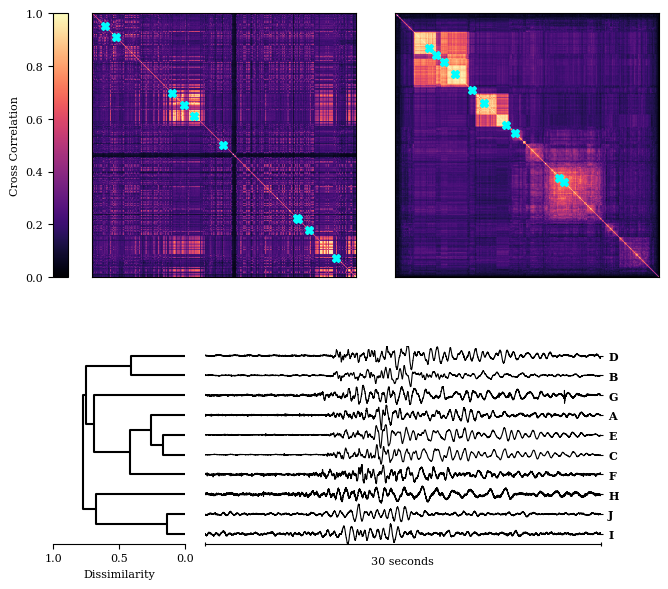

In [20]:
master_fig = plt.figure(figsize=(8,6))

xcorr_fig, dendro_fig = master_fig.subfigures(nrows=2,height_ratios=(2,1.5),hspace=0)

gs = xcorr_fig.add_gridspec(nrows=len(template_loc),ncols=3,width_ratios=[0.05,1,1],hspace=0,wspace=0.05)

cb_ax = xcorr_fig.add_subplot(gs[:,0])
chron_ax = xcorr_fig.add_subplot(gs[:,1])
sort_ax = xcorr_fig.add_subplot(gs[:,2])

cc_plot = chron_ax.imshow(cc_mat,cmap='magma',vmin=0,vmax=1)
chron_ax.set_xticks([])
chron_ax.set_yticks([])

cc_plot = sort_ax.imshow(cc_sort,cmap='magma',vmin=0,vmax=1)
sort_ax.set_xticks([])
sort_ax.set_yticks([])

plt.colorbar(cc_plot,cax=cb_ax,label='Cross Correlation')
cb_ax.yaxis.set_ticks_position('left')
cb_ax.yaxis.set_label_position('left')
cb_ax.set_ylim(0,1)

i = 0
for clust_id, loc in template_loc.items():
    chron_ax.plot(loc,loc,marker='X',color='cyan')
    if i % 2 == 0:
        va = 'top'
    else:
        va = 'bottom'
    i += 1

for event_id, loc in event_pos.items():
    sort_ax.plot(loc,loc,marker='X',color='cyan')


dendro_gs = dendro_fig.add_gridspec(ncols=3,width_ratios = [1,3,0.4],wspace=0.1)
dend_ax = dendro_fig.add_subplot(dendro_gs[0])
waveform_ax = dendro_fig.add_subplot(dendro_gs[1])

labels = ['A','B','C','D','E','F','G','H','I','J']
temp_labels = {num:labels[i] for i,num in enumerate(sort_temps.keys())}
cluster_nums = [key for key in templates.keys()]


dend_ax.spines['top'].set_visible(False)
dend_ax.spines['left'].set_visible(False)
dend_ax.spines['right'].set_visible(False)



waveform_ax.spines['top'].set_visible(False)
waveform_ax.spines['left'].set_visible(False)
waveform_ax.spines['right'].set_visible(False)

hierarchy.set_link_color_palette(['darkgreen','darkred','slategrey','peru','deeppink','olive'])

dendrogram = hierarchy.dendrogram(linkage,color_threshold=0,orientation='left',ax=dend_ax,labels=cluster_nums,no_labels=True,above_threshold_color='black')

dend_ax.set_xlim(1,0)
dend_ax.set_xlabel('Dissimilarity')

old_index = None
station_names = []
for i, cluster_num in enumerate(dendrogram['ivl']):
    template_id = templates[cluster_num]
    offset = 5 + i * 10

    temp_event = network_cat.select_event(template_id)
    temp_event.attach_waveforms(inv.select(station='TI3A',channel='CHZ'),raw_path,buffer=10,length=25)
    temp_event.filter('bandpass',freqmin=1,freqmax=100)  

    stream = temp_event.get_data_window()
    tr = stream.select(station='TI3A',channel='CHZ')[0]

    waveform_ax.plot(tr.times(),tr.data/tr.data.max()*5 + offset,lw=0.8,color='black')
    waveform_ax.set_xlim(0,30)

sorted_y_labels = [temp_labels[key] for key in dendrogram['ivl']]

waveform_ax.set_ylim((0,clusters.size*10))
waveform_ax.set_yticks(np.arange(0,clusters.size*10,10)+5)
waveform_ax.set_yticklabels(sorted_y_labels,weight='bold')
waveform_ax.yaxis.set_ticks_position('right')

waveform_ax.set_xticks([0,30])
waveform_ax.set_xticklabels(['',''])
waveform_ax.tick_params(direction='inout')
waveform_ax.set_xlabel('30 seconds')

master_fig.savefig(os.path.join(o_path,'FigS2_template_selection.pdf'),bbox_inches='tight')

In [21]:
for event_id, row in temp_cat.attributes.iterrows():
    time = UTCDateTime(temp_cat.events.at[event_id,'ref_time'])
    temp_cat.attributes.at[event_id,'time'] = time.matplotlib_date
    temp_cat.attributes.at[event_id,'diurnal'] = UTCDateTime(2018,1,1,time.hour,time.minute,time.second).matplotlib_date
    delta_t = time - t1
    temp_cat.attributes.at[event_id,'phase'] = np.interp(delta_t,dt,tidal_phase)
    temp_cat.attributes.at[event_id,'height'] = np.interp(delta_t,dt,tide)

In [22]:
stacked_streams = {}
for cluster_num in groups.keys():
    stream = read(os.path.join(w_path,'stacked_waveforms_cluster_'+str(cluster_num) + '.mseed'))
    stacked_streams[cluster_num] = stream

In [23]:
ss_temps = dict(sort_temps)
ss_temps.pop('116')
ss_temps.pop('117')

279

The distribution of the repeating events through the season derived from template matching can be visualised, with the following plot used as Figure 2 in the main text.

/var/folders/z4/gw28hj796zjdxt4nltp_h5g1m6cl00/T/ipykernel_65163/3283281629.py:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  group_cat.attributes.at[event_id,'time'] = time.matplotlib_date
/var/folders/z4/gw28hj796zjdxt4nltp_h5g1m6cl00/T/ipykernel_65163/3283281629.py:31: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  group_cat.attributes.at[event_id,'diurnal'] = UTCDateTime(2018,1,1,time.hour,time.minute,time.second).matplotlib_date
/var/folders/z4/gw28hj796zjdxt4nltp_h5g1m6cl00/T/ipykernel_65163/3283281

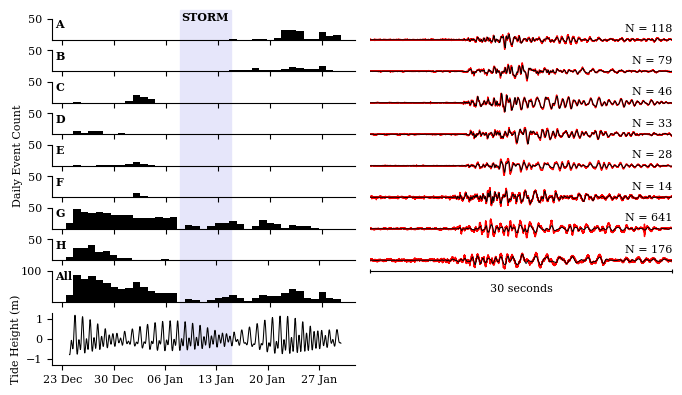

In [24]:
storm_start = UTCDateTime(2019,1,8).matplotlib_date
storm_end = UTCDateTime(2019,1,15).matplotlib_date


N_clust = len(ss_temps)
labels = ['A','B','C','D','E','F','G','H','I','J','K','L','M','N','O']
temp_labels = {num:labels[i] for i,num in enumerate(ss_temps.keys())}


fig = plt.figure(figsize=(8,4.5))
gs = fig.add_gridspec(nrows=3*(N_clust+3),ncols=2,wspace=0.05,hspace=0.0)

all_hist = []
all_tr = []

i = 0
for clust_num, pos in ss_temps.items():

    hist_ax = fig.add_subplot(gs[3*i:3*i+2,0])
    tr_ax = fig.add_subplot(gs[3*i+1:3*i+3,1])

    hist_ax.patch.set_alpha(0)

    all_hist.append(hist_ax)
    all_tr.append(tr_ax)

    group_cat = groups[int(clust_num)]
    for event_id, row in group_cat.attributes.iterrows():
        time = UTCDateTime(group_cat.events.at[event_id,'ref_time'])
        group_cat.attributes.at[event_id,'time'] = time.matplotlib_date
        group_cat.attributes.at[event_id,'diurnal'] = UTCDateTime(2018,1,1,time.hour,time.minute,time.second).matplotlib_date
        delta_t = time - t1
        group_cat.attributes.at[event_id,'phase'] = np.interp(delta_t,dt,tidal_phase)
        group_cat.attributes.at[event_id,'height'] = np.interp(delta_t,dt,tide)

    fine_bins = np.array([time.matplotlib_date for time in np.mgrid[chunk.starttime:chunk.endtime+1:24*60*60]])
    stalta_hist, _ = np.histogram(group_cat.attributes['time'],bins=fine_bins)

    hist_ax.bar(fine_bins[:-1],stalta_hist,width=np.diff(fine_bins),color='black')
    hist_ax.spines['top'].set_visible(False)
    hist_ax.spines['right'].set_visible(False)

    myFmt = DateFormatter("%d %b")
    hist_ax.xaxis.set_major_formatter(myFmt)
    hist_ax.xaxis.set_major_locator(DayLocator(interval=7))

    plt.setp(hist_ax.get_xticklabels(), visible=False)

    if i == 4:
        hist_ax.set_ylabel('Daily Event Count')

    stream = stacked_streams[int(clust_num)]

    template_id = templates[str(clust_num)]

    temp_event = network_cat.select_event(template_id)
    temp_event.attach_waveforms(inv.select(station='TI3A',channel='CHZ'),raw_path,buffer=10,length=25)
    
    temp_event.filter('bandpass',freqmin=1,freqmax=100)  

    t = stream.select(station='TI3A',component='Z')[0].times()

    tr_ax.plot(t,temp_event.get_data_window()[0].data,lw=1,color='red')
    tr_ax.plot(t,stream.select(station='TI3A',component='Z')[0].data,lw=0.7,c='k')    
    tr_ax.set_xlim(0,30)
    

    if i != N_clust-1:
        tr_ax.set_axis_off()



    else:
        tr_ax.spines['top'].set_visible(False)
        tr_ax.spines['left'].set_visible(False)
        tr_ax.spines['right'].set_visible(False)

        tr_ax.set_xticks([0,30])
        tr_ax.set_yticks([])
        tr_ax.set_xticklabels(['',''])
        tr_ax.tick_params(direction='inout')
        tr_ax.set_xlabel('30 seconds')

    N_group = groups[int(clust_num)].N

    tr_ax.annotate('N = ' + str(N_group),(1,1.25),xycoords='axes fraction',ha='right',va='top')
    hist_ax.annotate(temp_labels[clust_num],(0.01,1),xycoords='axes fraction',ha='left',va='top',weight='bold')

    # storm_box = Rectangle((storm_start,0),storm_end-storm_start,50,fc='lavender',zorder=-1)
    # hist_ax.add_patch(storm_box)

    i += 1

max_lim_hist = np.max(np.array([all_hist[i].get_ylim()[1] for i in range(N_clust)]))
max_lim_tr = np.max(np.array([np.max(np.abs(all_tr[i].get_ylim())) for i in range(N_clust)]))

for i in range(N_clust):
    all_hist[i].set_ylim(0,max_lim_hist)
    all_hist[i].set_yticks([50])

    max_y = np.max(np.abs(all_tr[i].get_ylim()))
    #all_tr[i].set_ylim(-max_lim_tr,max_lim_tr)
    all_tr[i].set_ylim(-max_y,max_y)

total_ax = fig.add_subplot(gs[3*(N_clust):3*(N_clust+1),0])
total_ax.patch.set_alpha(0)

stalta_hist, _ = np.histogram(temp_cat.attributes['time'],bins=fine_bins)

total_ax.bar(fine_bins[:-1],stalta_hist,width=np.diff(fine_bins),color='black')
total_ax.spines['top'].set_visible(False)
total_ax.spines['right'].set_visible(False)

# storm_box = Rectangle((storm_start,0),storm_end-storm_start,100,fc='lavender',zorder=-1)
# total_ax.add_patch(storm_box)

myFmt = DateFormatter("%d %b")
total_ax.xaxis.set_major_formatter(myFmt)
total_ax.xaxis.set_major_locator(DayLocator(interval=7))

plt.setp(total_ax.get_xticklabels(), visible=False)

total_ax.set_yticks([100])
total_ax.annotate('All',(0.01,1),xycoords='axes fraction',ha='left',va='top',weight='bold')



tide_ax = fig.add_subplot(gs[3*(N_clust+1)+1:,0],sharex=hist_ax)
tide_ax.patch.set_alpha(0)
tide_times = np.full(dt.size,fill_value=t1) + dt
tide_times_mt = np.array([time.matplotlib_date for time in tide_times])
tide_ax.plot(tide_times_mt,tide,lw=0.75,color='k')
tide_ax.set_ylim(-1.3,1.3)
tide_ax.set_ylabel('Tide Height (m)')
tide_ax.set_yticks([-1,0,1])
tide_ax.spines['top'].set_visible(False)
#tide_ax.spines['bottom'].set_visible(False)
tide_ax.spines['right'].set_visible(False)
# storm_box2 = Rectangle((storm_start,-1.3),storm_end-storm_start,17,fc='lavender',zorder=-10, clip_on=False)
# tide_ax.add_patch(storm_box2)

myFmt = DateFormatter("%d %b")
tide_ax.xaxis.set_major_formatter(myFmt)
tide_ax.xaxis.set_major_locator(DayLocator(interval=7))

left_fig_coords = fig.transFigure.inverted().transform(
    tide_ax.transData.transform((storm_start, -1.3))
)

right_fig_coords = fig.transFigure.inverted().transform(
    tide_ax.transData.transform((storm_end, -1.3))
)

rect = Rectangle(left_fig_coords, right_fig_coords[0]-left_fig_coords[0], 0.79, 
                         transform=fig.transFigure, 
                         color='lavender', 
                         zorder=-1)

fig.patches.append(rect)

fig.text((left_fig_coords[0]+right_fig_coords[0])/2,0.895,'STORM',ha='center',va='top',weight='bold')#,style='italic')

fig.savefig(os.path.join(o_path,'Fig2_template_catalogues.pdf'),bbox_inches='tight',dpi=400)

## Tide Analysis

In [25]:
#first do all the KL divergence calculations, but don't plot yet
#just need to save with the labels in the .csv for later...

dh = 0.05
height_x = np.mgrid[-1.5:1.5:dh]
ref_tide = gaussian_kde(tide).evaluate(height_x)

dphi = 10
phi = np.mgrid[-300:300:dphi]
ref_phase = gaussian_kde(tidal_phase).evaluate(phi)

neg_excess = ref_phase[phi<-180]
pos_excess = ref_phase[phi>180]
ref_phase[phi.size-neg_excess.size-pos_excess.size:-pos_excess.size] += neg_excess
ref_phase[neg_excess.size:neg_excess.size+pos_excess.size] += pos_excess
ref_phase = ref_phase[neg_excess.size:-pos_excess.size]

group_comp_height = {'116':np.nan,'117':np.nan}
group_comp_phase = {'116':np.nan,'117':np.nan}
group_KL_height = {'116':np.nan,'117':np.nan}
group_KL_phase = {'116':np.nan,'117':np.nan}

i = 1
for cluster_num, label in ss_temps.items():
    comp_tide = gaussian_kde(groups[int(cluster_num)].attributes['height']).evaluate(height_x)
    group_comp_height[cluster_num] = comp_tide
    kl = np.sum(rel_entr(comp_tide,ref_tide)*dh)
    group_KL_height[cluster_num] = kl
  

    comp_phase = gaussian_kde(groups[int(cluster_num)].attributes['phase']).evaluate(phi)
    neg_excess = comp_phase[phi<-180]
    pos_excess = comp_phase[phi>180]
    comp_phase[phi.size-neg_excess.size-pos_excess.size:-pos_excess.size] += neg_excess
    comp_phase[neg_excess.size:neg_excess.size+pos_excess.size] += pos_excess
    comp_phase = comp_phase[neg_excess.size:-pos_excess.size]
    group_comp_phase[cluster_num] = comp_phase
    kl = np.sum(rel_entr(comp_phase,ref_phase)*dphi)
    group_KL_phase[cluster_num] = kl

## Travel Time Inversion

Can set up the grid for the travel-time inversion grid search. This is done in polar stereographic coordinates, with the below grid found to contain the region where the events occur after manually apdapting the grid. Some local files such as grounding lines and an effective pressure model output are used for visualisation, but can be replaced by any desired product. This is mostly easily done by loading the data into an xarray format. 

In [26]:
xmin = 2.2615e6
xmax = 2.2735e6
ymin = -1.0060e6
ymax = -0.9940e6

resolution = 25 #m

xlin = np.mgrid[xmin:xmax:resolution]
ylin = np.mgrid[ymin:ymax:resolution]

V = 3870 #m/s est
dV = 100 #m/s std

Delta = 10000 #m

In [27]:
bed_grid = xr.Dataset(coords=dict(x=("x", xlin),y=("y", ylin)))
bedmap_interp = bedmap3.interp_like(bed_grid)
ep_interp = hydrology_data.interp_like(bed_grid)
vel_interp = vel_data.interp_like(bed_grid)
bed_grid = bed_grid.assign(dict(bed_topography = bedmap_interp.bed_topography,effective_pressure=ep_interp.effective_pressure,sheet_thickness=ep_interp.sheet_thickness,bed_uncertainty=bedmap_interp.bed_uncertainty,velX=vel_interp.VX,velY=vel_interp.VY))

In [28]:
bed_grid

<xarray.Dataset> Size: 15MB
Dimensions:             (x: 480, y: 480)
Coordinates:
  * x                   (x) float64 4kB 2.262e+06 2.262e+06 ... 2.273e+06
  * y                   (y) float64 4kB -1.006e+06 -1.006e+06 ... -9.94e+05
    lat                 (y, x) float64 2MB -67.5 -67.5 -67.5 ... -67.45 -67.45
    lon                 (y, x) float64 2MB 114.0 114.0 114.0 ... 113.6 113.6
Data variables:
    bed_topography      (y, x) float64 2MB -707.8 -709.3 ... -1.88e+03 -1.88e+03
    effective_pressure  (x, y) float64 2MB 1.707e+06 1.71e+06 ... 7.803e+05
    sheet_thickness     (x, y) float64 2MB 0.07572 0.07569 ... 0.07953 0.07952
    bed_uncertainty     (y, x) float64 2MB 42.5 39.45 36.4 ... 82.94 82.63 82.31
    velX                (y, x) float64 2MB 495.8 496.2 496.6 ... 83.12 82.9
    velY                (y, x) float64 2MB -523.9 -525.2 ... -635.4 -635.1

/Users/jmagyar/opt/miniconda3/envs/seismo_analysis/lib/python3.11/site-packages/shapely/predicates.py:798: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)
/Users/jmagyar/opt/miniconda3/envs/seismo_analysis/lib/python3.11/site-packages/shapely/set_operations.py:133: RuntimeWarning: invalid value encountered in intersection
  return lib.intersection(a, b, **kwargs)
/Users/jmagyar/opt/miniconda3/envs/seismo_analysis/lib/python3.11/site-packages/shapely/constructive.py:181: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(
/Users/jmagyar/opt/miniconda3/envs/seismo_analysis/lib/python3.11/site-packages/shapely/predicates.py:798: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)
/Users/jmagyar/opt/miniconda3/envs/seismo_analysis/lib/python3.11/site-packages/shapely/set_operations.py:133: RuntimeWarning: invalid value encountered in intersection
  return lib.intersection(a, b, 

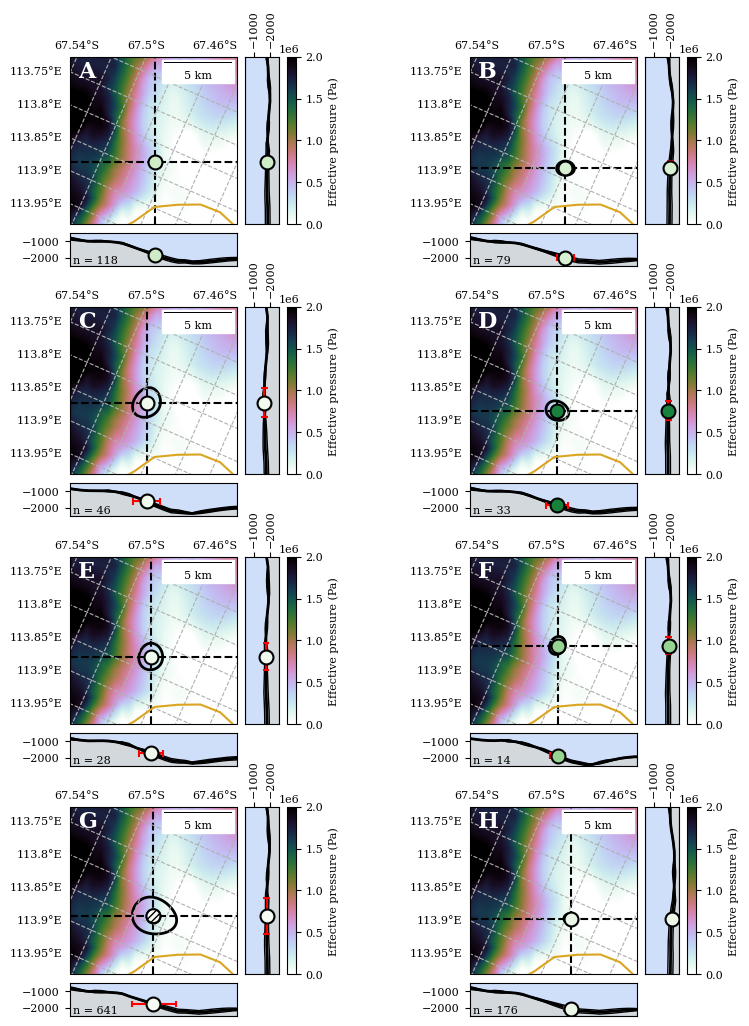

In [506]:
#loop over all the groups and combine into a large master figure...
#master_fig = plt.figure(figsize=(8.5,13))#,layout='constrained')
master_fig = plt.figure(figsize=(8,10))#,layout='constrained')

gs = master_fig.add_gridspec(nrows=8,ncols=4,height_ratios=4*[1,0.15],width_ratios=2*[1,0.15])
subfigs = [master_fig.add_subfigure(gs[(i//2)*2,(i%2)*2]) for i in range(8)]

cmap = plt.colormaps.get_cmap('Greens')

def cb_map(val,cb_min,cb_max):
    mapped = (val - cb_min) / (cb_max - cb_min)
    return mapped

cont = chi2.ppf(0.95,2)

for i, cluster_num in enumerate([31,43,34,44,33,32,39,54]):

    label = temp_labels[str(cluster_num)]
    tide_mod = group_KL_height[str(cluster_num)]
    color = cmap(cb_map(tide_mod,0,0.75)) #pick the colour based on the tidal skewness.

    
    p_picks = pd.read_csv(os.path.join(a_path,'manual_picks_' + str(cluster_num) + '.csv'),index_col=0)
    p_picks['mu'] = p_picks['P1'] + (p_picks['P2'] - p_picks['P1'])/2
    p_picks['sigma'] = (p_picks['P2'] - p_picks['P1'])/4


    gamma_xr = xr.load_dataset(os.path.join(m_path,'misfit_surface_'+str(cluster_num)+'.nc'))

    xlin = gamma_xr.x.to_numpy()
    ylin = gamma_xr.y.to_numpy()
    gamma = gamma_xr.gamma.to_numpy()

    
    x_ind, y_ind = np.unravel_index(np.argmin(gamma),gamma.shape)
    x_loc = xlin[x_ind]
    y_loc = ylin[y_ind]

    x_ind_err = np.where(gamma[:,y_ind] <= cont)[0]
    y_ind_err = np.where(gamma[x_ind,:] <= cont)[0]


    fig = subfigs[i]

    ne_ax = fig.add_subplot(111,projection = ccrs.SouthPolarStereo())
    gl = ne_ax.gridlines(crs=wgs84, draw_labels = {'top':'y','left':'x'}, linestyle = '--',x_inline=False,y_inline=False,rotate_labels=False)

    ne_ax.add_geometries(up_xy, crs=ccrs.epsg(3031), facecolor="none", edgecolor="goldenrod", linewidth=1.5,zorder=20)

    ep = bed_grid.effective_pressure.values


    pc_ep = ne_ax.pcolormesh(xlin,ylin,ep.T,cmap='cubehelix_r',vmin=0,vmax=2e6,shading='gouraud',transform=stereo,rasterized=True)
    #ep_c = ne_ax.contour(xlin,ylin,ep.T,levels=[0],colors=['lightgrey'],linewidths=[1],transform=stereo)

    #hatches = ne_ax.contourf(xlin,ylin,ep.T,levels=[-2.5e5,0], colors='none',hatches=['..'],transform=stereo)

    ne_ax.scatter(x_loc,y_loc,marker='o',s=100,zorder=5,color=color,edgecolors='black',linewidths=1.5,transform=stereo)

    if label == 'G':
        ne_ax.scatter(x_loc,y_loc,marker='o',s=100,zorder=5,color=color,edgecolors='black',linewidths=1.5,transform=stereo,hatch='/////')

    ne_ax.set_aspect('equal')

    ne_ax.contour(xlin,ylin,gamma.T,levels=[cont],colors=['black'],linewidths=[2],transform=stereo)


    for i, sta_name in enumerate(sta_lst):

        sta_x = sta_xy[i,0]
        sta_y = sta_xy[i,1]

        if (((sta_x <= xlin[-1]) & (sta_x >= xlin[0])) & ((sta_y <= ylin[-1]) & (sta_y >= ylin[0]))):
            ne_ax.scatter(sta_x,sta_y,marker='^',color='red',s=50,transform=stereo)
            ne_ax.annotate(sta_name,(sta_x,sta_y),c='white',weight='bold',zorder=5,size=10,transform=stereo)

    x_proj = ccrs.SouthPolarStereo().transform_points(ccrs.epsg(3031),xlin,np.full_like(xlin,y_loc))[:,0]
    y_proj = ccrs.SouthPolarStereo().transform_points(ccrs.epsg(3031),ylin,np.full_like(ylin,x_loc))[:,0]

    ne_ax.set_xlim((x_proj[0],x_proj[-1]))
    ne_ax.set_ylim((y_proj[0],y_proj[-1]))


    ez_ax = ne_ax.inset_axes(bounds = [0.0,-0.25,1,0.2],transform=ne_ax.transAxes,sharex=ne_ax)

    bed_x = bed_grid.isel(y=y_ind).bed_topography.values
    bed_dx = bed_grid.isel(y=y_ind).bed_uncertainty.values

    ez_ax.fill_between(x_proj,-2500,bed_x,color='slategrey',alpha=0.3)
    ez_ax.fill_between(x_proj,bed_x,-500,color='cornflowerblue',alpha=0.3)

    ez_ax.plot(x_proj,bed_x,lw=2,color='black')
    ez_ax.plot(x_proj,bed_x + bed_dx,lw=1,color='black')
    ez_ax.plot(x_proj,bed_x - bed_dx,lw=1,color='black')
    ez_ax.set_ylim(-2500,-500)

    nz_ax = ne_ax.inset_axes(bounds = [1.05,0,0.2,1],transform=ne_ax.transAxes,sharey=ne_ax)

    bed_y = bed_grid.isel(x=x_ind).bed_topography.values
    bed_dy = bed_grid.isel(x=x_ind).bed_uncertainty.values

    nz_ax.fill_betweenx(y_proj,bed_y,-2500,color='slategrey',alpha=0.3)
    nz_ax.fill_betweenx(y_proj,-500,bed_y,color='cornflowerblue',alpha=0.3)

    nz_ax.plot(bed_y,y_proj,lw=2,color='black')
    nz_ax.plot(bed_y + bed_dy,y_proj,lw=1,color='black')
    nz_ax.plot(bed_y - bed_dy,y_proj,lw=1,color='black')
    nz_ax.set_xlim(-500,-2500)

    ne_ax.hlines(ylin[y_ind],xmin=xlin[0],xmax=xlin[-1],color='black',ls='--',transform=stereo)
    ne_ax.vlines(xlin[x_ind],ymin=ylin[0],ymax=ylin[-1],color='black',ls='--',transform=stereo)

    ez_ax.scatter(x_proj[x_ind],bed_x[x_ind],marker='o',s=100,zorder=5,color=color,edgecolors='black',linewidths=1.5)
    nz_ax.scatter(bed_y[y_ind],y_proj[y_ind],marker='o',s=100,zorder=5,color=color,edgecolors='black',linewidths=1.5)

    x_range = (x_proj[np.min(x_ind_err)],x_proj[np.max(x_ind_err)])
    y_range = (y_proj[np.min(y_ind_err)],y_proj[np.max(y_ind_err)])

    ez_ax.hlines(bed_x[x_ind],xmin=x_range[0],xmax=x_range[1],color='red')
    ez_ax.vlines(x_range,ymin=bed_x[x_ind]-200,ymax=bed_x[x_ind]+200,color='red')

    nz_ax.vlines(bed_y[y_ind],ymin=y_range[0],ymax=y_range[1],color='red')
    nz_ax.hlines(y_range,xmin=bed_y[y_ind]-200,xmax=bed_y[y_ind]+200,color='red')

    ez_ax.set_xticks([])
    nz_ax.set_yticks([])

    nz_ax.tick_params(axis='x', labelrotation=90)


    nz_ax.xaxis.set_ticks_position('top')

    cb_ax = ne_ax.inset_axes(bounds = [1.3,0,0.05,1],transform=ne_ax.transAxes)
    clb = fig.colorbar(pc_ep, cax = cb_ax)
    clb.set_label('Effective pressure (Pa)')
    cb_ax.yaxis.get_offset_text().set_position((1.5,1))


    scalebar = ScaleBar(0.001, "km", length_fraction=0.25,border_pad=0.25,fixed_value=5)
    ne_ax.add_artist(scalebar)
    ne_ax.annotate(label,(0.05,0.88),xycoords='axes fraction',c='white',fontsize=16,weight='bold')
    
    N_group = groups[int(cluster_num)].N
    ez_ax.annotate('n = ' + str(N_group),(0.02,0.03),xycoords='axes fraction',ha='left',va='bottom')


master_fig.savefig(os.path.join(o_path,'FigS3_travel_time_inversion.pdf'),bbox_inches='tight',dpi=400)

/Users/jmagyar/opt/miniconda3/envs/seismo_analysis/lib/python3.11/site-packages/shapely/predicates.py:798: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)
/Users/jmagyar/opt/miniconda3/envs/seismo_analysis/lib/python3.11/site-packages/shapely/set_operations.py:133: RuntimeWarning: invalid value encountered in intersection
  return lib.intersection(a, b, **kwargs)
/Users/jmagyar/opt/miniconda3/envs/seismo_analysis/lib/python3.11/site-packages/shapely/constructive.py:181: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(
/Users/jmagyar/opt/miniconda3/envs/seismo_analysis/lib/python3.11/site-packages/shapely/constructive.py:181: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(
/Users/jmagyar/opt/miniconda3/envs/seismo_analysis/lib/python3.11/site-packages/shapely/constructive.py:181: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(
/Users/jmagyar/opt/miniconda3/envs/seism

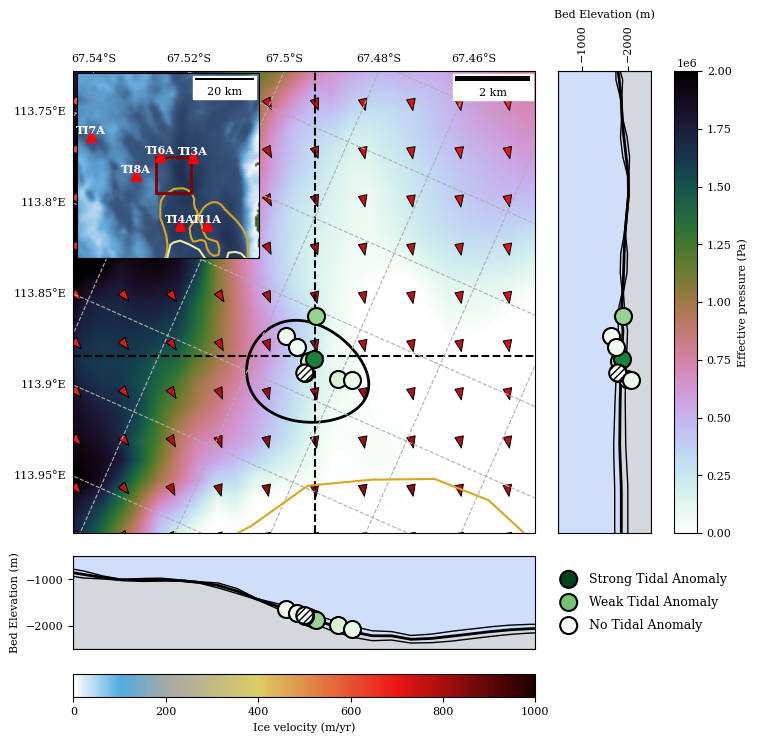

In [507]:
fig = plt.figure(figsize=(6,6))

ne_ax = fig.add_subplot(111,projection = ccrs.SouthPolarStereo())
#ne_ax = fig.add_subplot(111,projection = stereo)
ez_ax = ne_ax.inset_axes(bounds = [0.0,-0.25,1,0.2],transform=ne_ax.transAxes,sharex=ne_ax)
nz_ax = ne_ax.inset_axes(bounds = [1.05,0,0.2,1],transform=ne_ax.transAxes,sharey=ne_ax)
dot_ax = ne_ax.inset_axes(bounds = [1.05,-0.25,0.2,0.2],transform=ne_ax.transAxes)

gl = ne_ax.gridlines(crs=wgs84, draw_labels = {'top':'y','left':'x'}, linestyle = '--',x_inline=False,y_inline=False,rotate_labels=False)

ne_ax.add_geometries(up_xy, crs=ccrs.epsg(3031), facecolor="none", edgecolor="goldenrod", linewidth=1.5,zorder=20)

ep = bed_grid.effective_pressure.values
ep[ep<=0.0] = -2e5

pc_ep = ne_ax.pcolormesh(xlin,ylin,ep.T,cmap='cubehelix_r',vmin=0,vmax=2e6,shading='gouraud',transform=stereo,rasterized=True)

skip = 50

X, Y = np.meshgrid(xlin[::skip], ylin[::skip])
XYT = ne_ax.projection.transform_points(stereo,X,Y)
X1 = XYT[:,:,0]
Y1 = XYT[:,:,1]

U = bed_grid.velX.values[::skip, ::skip]
V = bed_grid.velY.values[::skip, ::skip]

mag = np.sqrt(U**2 + V**2)

Uhat = U / mag
Vhat = V / mag

Uhat[mag <= 50] = np.nan
Vhat[mag <= 50] = np.nan


ne_ax.quiver(X1,Y1,Uhat,Vhat,mag,cmap=vel_cmap,scale=40,headwidth=6,headlength=8,headaxislength=8,edgecolor='black',linewidth=0.7,norm=Normalize(vmin=0,vmax=1000))

ne_ax.set_aspect('equal')

x_tot = 0.0
y_tot = 0.0

for i, cluster_num in enumerate([31,43,34,44,33,32,39,54]):

    label = temp_labels[str(cluster_num)]
    kl_height = group_KL_height[str(cluster_num)]

    gamma_xr = xr.load_dataset(os.path.join(m_path,'misfit_surface_'+str(cluster_num)+'.nc'))

    xlin = gamma_xr.x.to_numpy()
    ylin = gamma_xr.y.to_numpy()
    gamma = gamma_xr.gamma.to_numpy()

    x_ind, y_ind = np.unravel_index(np.argmin(gamma),gamma.shape)
    x_loc = xlin[x_ind]
    y_loc = ylin[y_ind]

    z_loc = bed_grid.bed_topography.isel(x=x_ind,y=y_ind)

    x_tot += x_loc
    y_tot += y_loc

    color = cmap(cb_map(kl_height,0,0.75)) #pick the colour based on the tidal skewness.

    ne_ax.scatter(x_loc,y_loc,marker='o',s=150,zorder=5,color=color,edgecolors='black',linewidths=1.5,transform=stereo)

    if label == 'G':
        ne_ax.contour(xlin,ylin,gamma.T,levels=[cont],colors=['black'],linewidths=[2],transform=stereo)
        ne_ax.scatter(x_loc,y_loc,marker='o',s=150,zorder=5,color=color,edgecolors='black',linewidths=1.5,transform=stereo,hatch='/////')

    x_proj = ccrs.SouthPolarStereo().transform_points(ccrs.epsg(3031),xlin,np.full_like(xlin,y_loc))[:,0]
    y_proj = ccrs.SouthPolarStereo().transform_points(ccrs.epsg(3031),ylin,np.full_like(ylin,x_loc))[:,0]

    ez_ax.scatter(x_proj[x_ind],z_loc,marker='o',s=150,zorder=5,color=color,edgecolors='black',linewidths=1.5)
    nz_ax.scatter(z_loc,y_proj[y_ind],marker='o',s=150,zorder=5,color=color,edgecolors='black',linewidths=1.5)

    if label == 'G':
        ez_ax.scatter(x_proj[x_ind],z_loc,marker='o',s=150,zorder=5,color=color,edgecolors='black',linewidths=1.5,hatch='/////')
        nz_ax.scatter(z_loc,y_proj[y_ind],marker='o',s=150,zorder=5,color=color,edgecolors='black',linewidths=1.5,hatch='/////')


mean_x = x_tot / 8
mean_y = y_tot / 8

for i, sta_name in enumerate(sta_lst):

    sta_x = sta_xy[i,0]
    sta_y = sta_xy[i,1]

    if (((sta_x <= xlin[-1]) & (sta_x >= xlin[0])) & ((sta_y <= ylin[-1]) & (sta_y >= ylin[0]))):
        ne_ax.scatter(sta_x,sta_y,marker='^',color='red',s=50,transform=stereo)
        ne_ax.annotate(sta_name,(sta_x,sta_y),c='white',weight='bold',zorder=5,size=10,transform=stereo,va='bottom')



ne_ax.set_xlim((x_proj[0],x_proj[-1]))
ne_ax.set_ylim((y_proj[0],y_proj[-1]))

bed_x = bed_grid.interp(y=mean_y).bed_topography.values
bed_dx = bed_grid.interp(y=mean_y).bed_uncertainty.values

ez_ax.fill_between(x_proj,-2500,bed_x,color='slategrey',alpha=0.3)
ez_ax.fill_between(x_proj,bed_x,-500,color='cornflowerblue',alpha=0.3)

ez_ax.plot(x_proj,bed_x,lw=2,color='black')
ez_ax.plot(x_proj,bed_x + bed_dx,lw=1,color='black')
ez_ax.plot(x_proj,bed_x - bed_dx,lw=1,color='black')
ez_ax.set_yticks([-1000,-2000])
ez_ax.set_ylim(-2500,-500)


bed_y = bed_grid.interp(x=mean_x).bed_topography.values
bed_dy = bed_grid.interp(x=mean_x).bed_uncertainty.values

nz_ax.fill_betweenx(y_proj,bed_y,-2500,color='slategrey',alpha=0.3)
nz_ax.fill_betweenx(y_proj,-500,bed_y,color='cornflowerblue',alpha=0.3)

nz_ax.plot(bed_y,y_proj,lw=2,color='black')
nz_ax.plot(bed_y + bed_dy,y_proj,lw=1,color='black')
nz_ax.plot(bed_y - bed_dy,y_proj,lw=1,color='black')
nz_ax.set_xticks([-1000,-2000])
nz_ax.set_xlim(-500,-2500)

ne_ax.hlines(mean_y,xmin=xlin[0],xmax=xlin[-1],color='black',ls='--',transform=stereo)
ne_ax.vlines(mean_x,ymin=ylin[0],ymax=ylin[-1],color='black',ls='--',transform=stereo)

ez_ax.set_xticks([])
nz_ax.set_yticks([])

nz_ax.tick_params(axis='x', labelrotation=90)


nz_ax.xaxis.set_ticks_position('top')

ez_ax.set_ylabel('Bed Elevation (m)')
nz_ax.set_xlabel('Bed Elevation (m)')

nz_ax.xaxis.set_label_position('top')

cb_ax = ne_ax.inset_axes(bounds = [1.3,0,0.05,1],transform=ne_ax.transAxes)
clb = fig.colorbar(pc_ep, cax = cb_ax)
clb.set_label('Effective pressure (Pa)')

cb_ax2 = ne_ax.inset_axes(bounds = [0,-0.355,1,0.05],transform=ne_ax.transAxes)
clb = fig.colorbar(plt.cm.ScalarMappable(plt.Normalize(0,1000),cmap=vel_cmap), cax = cb_ax2,orientation='horizontal')
clb.set_label('Ice velocity (m/yr)')


scalebar = ScaleBar(0.001, "km", length_fraction=0.25,border_pad=0.25,fixed_value=2)
ne_ax.add_artist(scalebar)

dot_c = cmap(cb_map(np.array([0,0.5,1]),0,1))
dot_ax.scatter([0,0,0],[1,2,3],c=dot_c,marker='o',s=150,zorder=5,edgecolors='black',linewidths=1.5)

dot_ax.set_ylim(0,4)
dot_ax.set_xlim(-0.5,4)
dot_ax.set_axis_off()

dot_ax.annotate('Strong Tidal Anomaly',xy=(1,3),ha='left',va='center',fontsize=9)
dot_ax.annotate('Weak Tidal Anomaly',xy=(1,2),ha='left',va='center',fontsize=9)
dot_ax.annotate('No Tidal Anomaly',xy=(1,1),ha='left',va='center',fontsize=9)

inset_ax = ne_ax.inset_axes(bounds = [0.005, 1-0.4-0.005, 0.4, 0.4], transform = ne_ax.transAxes, projection = ccrs.SouthPolarStereo(),zorder=50)
inset_ax.set_extent([113.2, 114.3, -67.7, -67.3],crs=wgs84)


inset_grid = xr.Dataset(coords=dict(x=("x", np.mgrid[2.2e6:2.3e6:500]),y=("y", np.mgrid[-1.1e6:-0.95e6:500])))
bedmap_interp = bedmap3.interp_like(inset_grid)
inset_grid = inset_grid.assign(dict(bed_topography = bedmap_interp.bed_topography))

inset_ax.pcolormesh(inset_grid.x,inset_grid.y,inset_grid.bed_topography,shading='gouraud',rasterized=True, transform=stereo,cmap = cmap_bedmachine(),vmin=-3000,vmax=3000)

_, inset_indicator = inset_ax.indicate_inset_zoom(ne_ax, edgecolor = 'maroon',alpha=1,linewidth=2,zorder=25) # indicate on main axes the inset axes

for connector in inset_indicator:
    connector.set_visible(False)


inset_ax.add_geometries(up_xy, crs=ccrs.epsg(3031), facecolor="none", edgecolor="goldenrod", linewidth=1.5,zorder=20)
inset_ax.add_geometries(dn_ll, crs=ccrs.epsg(3031), facecolor="none", edgecolor="palegoldenrod", linewidth=1.5, zorder=20)
inset_ax.add_geometries(isl_ll, crs=ccrs.epsg(3031), facecolor="none", edgecolor="white", linewidth=1.5, zorder=20)


for i, sta_name in enumerate(sta_lst):

    sta_x = sta_xy[i,0]
    sta_y = sta_xy[i,1]

    inset_ax.scatter(sta_x,sta_y,marker='^',color='red',s=50,transform=stereo,zorder=30)
    inset_ax.annotate(sta_name,(sta_x,sta_y),c='white',weight='bold',zorder=30,size=8,transform=stereo,ha='center',va='bottom')


scalebar = ScaleBar(0.001, "km", length_fraction=0.25,border_pad=0.25,fixed_value=20)
inset_ax.add_artist(scalebar)

fig.savefig(os.path.join(o_path,'Fig3_cluster_tide_locations.pdf'),bbox_inches='tight',dpi=400)

/Users/jmagyar/opt/miniconda3/envs/seismo_analysis/lib/python3.11/site-packages/pyproj/crs/crs.py:141: FutureWarning: '+init=<authority>:<code>' syntax is deprecated. '<authority>:<code>' is the preferred initialization method. When making the change, be mindful of axis order changes: https://pyproj4.github.io/pyproj/stable/gotchas.html#axis-order-changes-in-proj-6
  in_crs_string = _prepare_from_proj_string(in_crs_string)
/Users/jmagyar/opt/miniconda3/envs/seismo_analysis/lib/python3.11/site-packages/pyproj/crs/crs.py:141: FutureWarning: '+init=<authority>:<code>' syntax is deprecated. '<authority>:<code>' is the preferred initialization method. When making the change, be mindful of axis order changes: https://pyproj4.github.io/pyproj/stable/gotchas.html#axis-order-changes-in-proj-6
  in_crs_string = _prepare_from_proj_string(in_crs_string)
/Users/jmagyar/Documents/icequakecode/cryoquake/src/cryoquake/spatial_analysis.py:808: FutureWarning: This function is deprecated. See: https://py

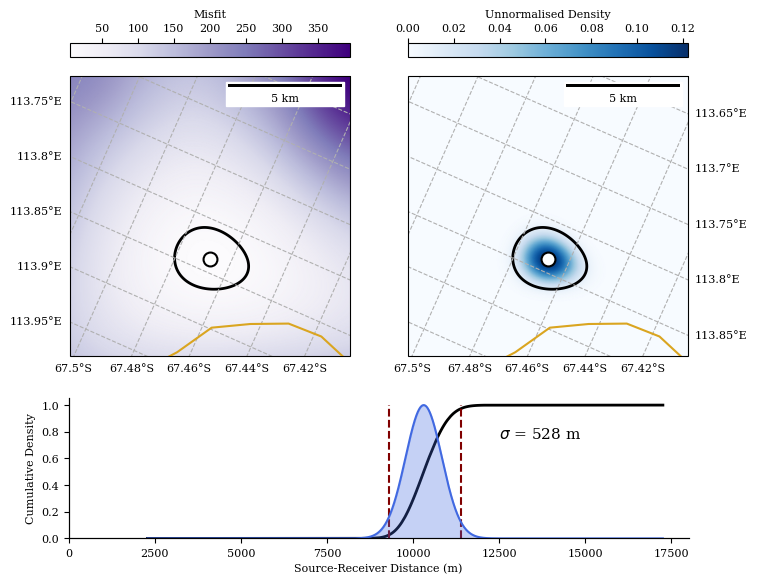

In [508]:
gamma_xr = xr.load_dataset(os.path.join(m_path,'misfit_surface_'+str(39)+'.nc'))

fig = plt.figure(figsize=(8,6))

gs = fig.add_gridspec(ncols=2,nrows=2,height_ratios=[2,1])

chi2_surf = (gamma_xr.chi2 / gamma_xr.chi2.min()) * (7 - 2)
gamma = gamma_xr.gamma.to_numpy()

x_ind, y_ind = np.unravel_index(np.argmin(gamma),gamma.shape)
x_loc = xlin[x_ind]
y_loc = ylin[y_ind]

x_ind_err = np.where(gamma[:,y_ind] <= cont)[0]
y_ind_err = np.where(gamma[x_ind,:] <= cont)[0]


chi2_ax = fig.add_subplot(gs[0,0],projection = ccrs.SouthPolarStereo())
gl = chi2_ax.gridlines(crs=wgs84, draw_labels = {'bottom':'y','left':'x'}, linestyle = '--',x_inline=False,y_inline=False,rotate_labels=False)

chi2_ax.add_geometries(up_xy, crs=ccrs.epsg(3031), facecolor="none", edgecolor="goldenrod", linewidth=1.5,zorder=20)


pc_chi2 = chi2_ax.pcolormesh(xlin,ylin,chi2_surf.T,cmap='Purples',shading='gouraud',transform=stereo,rasterized=True)

chi2_ax.scatter(x_loc,y_loc,marker='o',s=100,zorder=5,color='white',edgecolors='black',linewidths=1.5,transform=stereo)
chi2_ax.set_aspect('equal')

chi2_ax.contour(xlin,ylin,gamma.T,levels=[cont],colors=['black'],linewidths=[2],transform=stereo)
#ne_ax.contour(xlin,ylin,gamma_simple.T,levels=[cont],colors=['black'],linewidths=[1.5],linestyles=['--'],transform=stereo)


for i, sta_name in enumerate(sta_lst):

    sta_x = sta_xy[i,0]
    sta_y = sta_xy[i,1]

    if (((sta_x <= xlin[-1]) & (sta_x >= xlin[0])) & ((sta_y <= ylin[-1]) & (sta_y >= ylin[0]))):
        chi2_ax.scatter(sta_x,sta_y,marker='^',color='red',s=50,transform=stereo)
        chi2_ax.annotate(sta_name,(sta_x,sta_y),c='white',weight='bold',zorder=5,size=10,transform=stereo)


cb_ax = chi2_ax.inset_axes(bounds = [0,1.07,1,0.05],transform=chi2_ax.transAxes)
clb = fig.colorbar(pc_chi2, cax = cb_ax,orientation='horizontal')
clb.set_label('Misfit')
cb_ax.xaxis.set_ticks_position('top')
cb_ax.xaxis.set_label_position('top')


scalebar = ScaleBar(0.001, "km", length_fraction=0.25,border_pad=0.5,fixed_value=5)
chi2_ax.add_artist(scalebar)


pdf = chi2.pdf(chi2_surf,5)


pdf_ax = fig.add_subplot(gs[0,1],projection = ccrs.SouthPolarStereo())
gl = pdf_ax.gridlines(crs=wgs84, draw_labels = {'bottom':'y','right':'x'}, linestyle = '--',x_inline=False,y_inline=False,rotate_labels=False)

pdf_ax.add_geometries(up_xy, crs=ccrs.epsg(3031), facecolor="none", edgecolor="goldenrod", linewidth=1.5,zorder=20)


pc_pdf = pdf_ax.pcolormesh(xlin,ylin,pdf.T,cmap='Blues',shading='gouraud',transform=stereo,rasterized=True)

pdf_ax.scatter(x_loc,y_loc,marker='o',s=100,zorder=5,color='white',edgecolors='black',linewidths=1.5,transform=stereo)
pdf_ax.set_aspect('equal')

pdf_ax.contour(xlin,ylin,gamma.T,levels=[cont],colors=['black'],linewidths=[2],transform=stereo)
#ne_ax.contour(xlin,ylin,gamma_simple.T,levels=[cont],colors=['black'],linewidths=[1.5],linestyles=['--'],transform=stereo)


for i, sta_name in enumerate(sta_lst):

    sta_x = sta_xy[i,0]
    sta_y = sta_xy[i,1]

    if (((sta_x <= xlin[-1]) & (sta_x >= xlin[0])) & ((sta_y <= ylin[-1]) & (sta_y >= ylin[0]))):
        pdf_ax.scatter(sta_x,sta_y,marker='^',color='red',s=50,transform=stereo)
        pdf_ax.annotate(sta_name,(sta_x,sta_y),c='white',weight='bold',zorder=5,size=10,transform=stereo)


cb_ax = pdf_ax.inset_axes(bounds = [0,1.07,1,0.05],transform=pdf_ax.transAxes)
clb = fig.colorbar(pc_pdf, cax = cb_ax,orientation='horizontal')
clb.set_label('Unnormalised Density')
cb_ax.xaxis.set_ticks_position('top')
cb_ax.xaxis.set_label_position('top')


scalebar = ScaleBar(0.001, "km", length_fraction=0.25,border_pad=0.5,fixed_value=5)
pdf_ax.add_artist(scalebar)

radial_ax = fig.add_subplot(gs[1,:])


d, _ = sa.DistXr(inv,bed_grid)
r_i = d.variables['TI3A']

r_i_flat = r_i.to_numpy().flatten()

ind_sort = np.argsort(r_i_flat)

r_i_sort = r_i_flat[ind_sort]
pdf_flat = pdf.flatten()

chi2_sort = pdf_flat[ind_sort]

cdf_r = np.cumsum(chi2_sort)
cdf_r /= cdf_r[-1]

ci = r_i_sort[(cdf_r >= 0.025) & (cdf_r <= 0.975)]
med = r_i_sort[np.argmin(np.abs(cdf_r - 0.5))]
sigma = (ci[-1] - ci[0]) / 4

radial_ax.plot(r_i_sort,cdf_r,color='black',lw=2)
radial_ax.vlines((ci[0],ci[-1]),ymin=0,ymax=1,color='maroon',ls='--')

norm_ax = radial_ax.twinx()

norm_dist = norm.pdf(r_i_sort,loc=med,scale=sigma)
norm_ax.plot(r_i_sort,norm_dist,color='royalblue')
norm_ax.fill_between(r_i_sort,0,norm_dist,color='royalblue',alpha=0.3)
norm_ax.set_yticks([])

radial_ax.spines['top'].set_visible(False)
radial_ax.spines['right'].set_visible(False)
norm_ax.spines['top'].set_visible(False)
norm_ax.spines['right'].set_visible(False)

radial_ax.set_ylim(bottom=0)
norm_ax.set_ylim(bottom=0)
radial_ax.set_xlim(left=0)

radial_ax.set_xlabel('Source-Receiver Distance (m)')
radial_ax.set_ylabel('Cumulative Density')

#annotate with the error estimate...

radial_ax.annotate('$\sigma$ = {:.0f} m'.format(sigma),(12500,0.75),fontsize=11)

fig.savefig(os.path.join(o_path,'FigS4_radial_error_est.pdf'),bbox_inches='tight',dpi=400)

## Magnitude Calculations

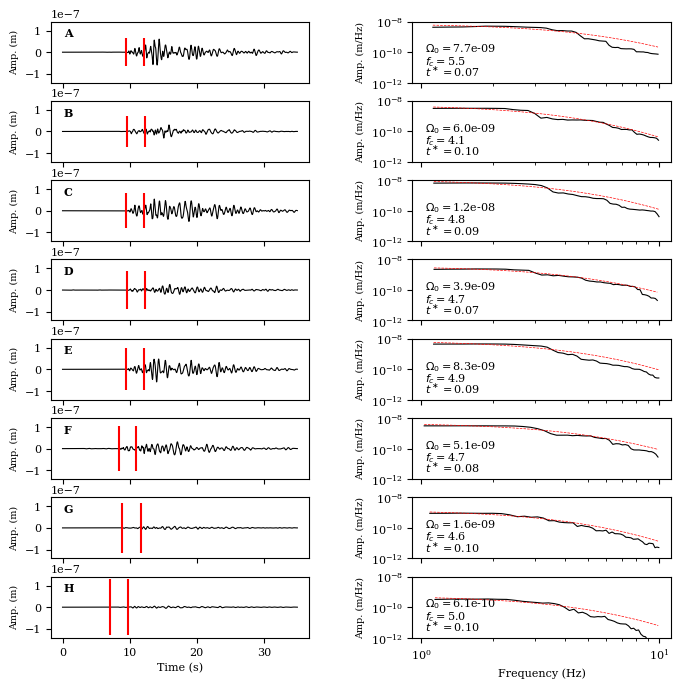

In [509]:
fig, ax = plt.subplots(nrows=len(groups),ncols=2,figsize=(8,8),sharex='col',sharey='col',gridspec_kw={'wspace':0.4,'hspace':0.3})
sta_code = 'TI3A'

i = 0
for cluster_num, label in temp_labels.items():
    cluster_num = int(cluster_num)

    gamma_xr = xr.load_dataset(os.path.join(m_path,'misfit_surface_'+str(cluster_num)+'.nc'))
    arrivals = mm.Misfit2Arrivals(gamma_xr)

    stations = gamma_xr.stations

    stacked_stream = read(os.path.join(w_path,'stacked_waveforms_cluster_' + str(cluster_num) + '.mseed'))
    stacked_stream.filter('bandpass',freqmin=1,freqmax=10)

    ref_energy = {}

    for tr in stacked_stream:
        if tr.stats.station not in gamma_xr.stations:
            stacked_stream.remove(tr)

    for tr in stacked_stream:
        tr.stats.starttime = UTCDateTime(2019,1,10)
        tr.remove_response(inv,output='DISP')


    sta_mag = mm.StationMomentMagnitude(stacked_stream,arrivals,freqmin=1,freqmax=10)
    theta_dict, theta_unc_dict = mm.IncidenceAngle(stacked_stream,arrivals,freqmin=1,freqmax=10)
    f_dict, Pxx_dict, ci_dict, err_dict = mm.SourceSpectrum(stacked_stream,arrivals,freqmin=1,freqmax=10)


    P_start = arrivals['P_start'][sta_code]
    P_end = P_start + arrivals['P_window'][sta_code]
    tr = stacked_stream.select(station=sta_code,channel='CHZ')[0]
    fs = tr.stats.sampling_rate
    ax[i,0].plot(tr.times(),tr.data,color='black',lw=0.8,rasterized=True)
    ylims = ax[i,0].get_ylim()
    ax[i,0].vlines([P_start,P_end],ymin=ylims[0],ymax=ylims[1],color='red')

    ax[i,0].annotate(label,(0.05,0.9),xycoords='axes fraction',va='top',weight='bold')



    Pxx = Pxx_dict[sta_code]
    freq = f_dict[sta_code]
    t = (arrivals['R']/3870)[sta_code]


    logomega0 = sta_mag['logomega0'][sta_code]
    fc = sta_mag['fc'][sta_code]
    t_star = sta_mag['t_star'][sta_code]

    omega = mm.LogBruneModel(freq,logomega0,fc,t_star)

    ax[i,1].plot(freq,Pxx,color='black',lw=0.8,rasterized=True)
    ax[i,1].set_xscale('log')
    ax[i,1].set_yscale('log')

    ax[i,1].plot(freq,omega,color='red',ls='--',lw=0.5,rasterized=True)
    ax[i,1].annotate(r'$\Omega_0=${:.1e}'.format(np.exp(logomega0)),(0.05,0.5),xycoords='axes fraction')
    ax[i,1].annotate(r'$f_c=${:.1f}'.format(fc),(0.05,0.3),xycoords='axes fraction')
    ax[i,1].annotate(r'$t^\ast=${:.2f}'.format(t_star),(0.05,0.1),xycoords='axes fraction')

    ax[i,0].set_ylabel('Amp. (m)',fontsize=7)
    ax[i,1].set_ylabel('Amp. (m/Hz)',fontsize=7)

    ax[i,1].set_ylim(1e-12,1e-8)
    ax[i,1].set_yticks([1e-12,1e-10,1e-8])

    i += 1

ax[-1,0].set_xlabel('Time (s)')
ax[-1,1].set_xlabel('Frequency (Hz)')

fig.savefig(os.path.join(o_path,'FigS5_brune_fit_cluster.pdf'),bbox_inches='tight',dpi=400)

In [510]:
moment_mags = chunk.load_csv(os.path.join(c_path,'network'),'moment_magnitude')
temp_cat.attributes['Mw'] = moment_mags['Mw']
temp_cat.attributes['M0'] = moment_mags['M0']
groups = temp_cat.group_split()

ss_cat = groups[54] + groups[39] + groups[44] + groups[34] + groups[33] + groups[43] + groups[32] + groups[31]
times = temp_cat.event_times

In [511]:
ind = temp_cat.events[(temp_cat.events['group'] == 116) | (temp_cat.events['group'] == 117)].index
event_times = temp_cat.events.drop(ind)['ref_time'].to_numpy()
event_times = np.array([UTCDateTime(time) for time in event_times],dtype=UTCDateTime)
delta_t = np.diff(event_times)
Mw_dt = temp_cat.attributes.drop(ind)['Mw'].to_numpy()[1:]
delta_t /= (60)

In [512]:
def cb_map(val,cb_min,cb_max):
    mapped = (val - cb_min) / (cb_max - cb_min)
    return mapped

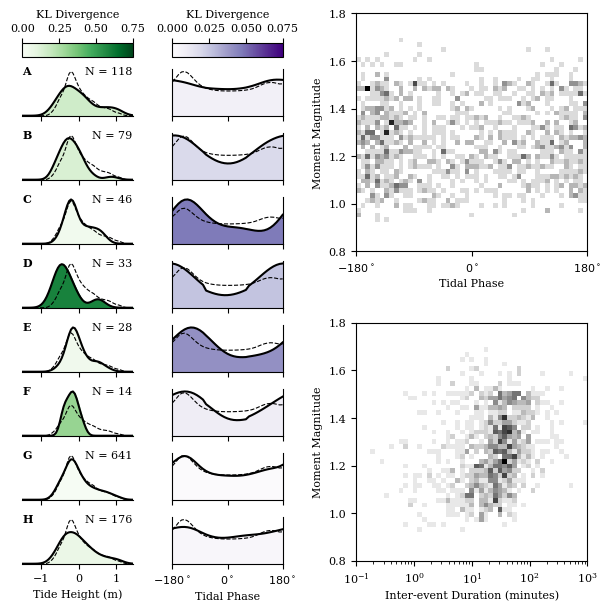

In [513]:
master_fig = plt.figure(figsize=(6,6),layout='constrained')

fig, scatter_fig = master_fig.subfigures(ncols=2)
gs = fig.add_gridspec(ncols=2,nrows=9, height_ratios= [0.3] + 8*[1])

cmap_greens = plt.colormaps.get_cmap('Greens')
cmap_reds = plt.colormaps.get_cmap('Purples')


i = 1
for cluster_num, label in ss_temps.items():
    height_ax = fig.add_subplot(gs[i,0])
    phase_ax = fig.add_subplot(gs[i,1])

    comp_tide = group_comp_height[str(cluster_num)]
    kl = group_KL_height[str(cluster_num)]
    height_ax.plot(height_x,comp_tide,c='black',lw=1.5)
    height_ax.annotate(temp_labels[str(cluster_num)],xy=(0,0.9),xycoords='axes fraction',weight='bold',fontsize=8)
    height_ax.annotate('N = ' + str(groups[int(cluster_num)].N),xy=(1,0.9),xycoords='axes fraction',fontsize=8,ha='right')
    height_ax.fill_between(height_x,comp_tide,color=cmap_greens(cb_map(kl,0,0.75)))
    height_ax.plot(height_x,ref_tide,c='k',lw=0.8,ls='--')

    height_ax.spines['top'].set_visible(False)
    height_ax.spines['left'].set_visible(False)
    height_ax.spines['right'].set_visible(False)
    height_ax.set_yticks([])
    #height_ax.vlines(np.mean(tide),ymin=0,ymax=height_ax.get_ylim()[1],lw=2,color='black',ls='--')
    height_ax.set_ylim(bottom=0)
    height_ax.set_xlim(height_x[0],height_x[-1])

    comp_phase = group_comp_phase[str(cluster_num)]
    kl = group_KL_phase[str(cluster_num)]
    phase_ax.plot(phi[neg_excess.size:-pos_excess.size],ref_phase,c='k',lw=0.8,ls='--')
    phase_ax.plot(phi[neg_excess.size:-pos_excess.size],comp_phase,c='black',lw=1.5)
    phase_ax.fill_between(phi[neg_excess.size:-pos_excess.size],comp_phase,color=cmap_reds(cb_map(kl,0,0.075)))
    phase_ax.spines['top'].set_visible(False)
    phase_ax.set_yticks([])
    phase_ax.set_ylim(bottom=0)
    phase_ax.set_xlim(-180,180)
    phase_ax.set_xticks([-180,0,180],labels=[r'$-180^\circ$',r'$0^\circ$',r'$180^\circ$'])


    if i != 8:
        plt.setp(phase_ax.get_xticklabels(), visible=False)
        plt.setp(height_ax.get_xticklabels(), visible=False)

    else:
        height_ax.set_xlabel('Tide Height (m)')
        phase_ax.set_xlabel('Tidal Phase')

    i += 1

height_cb_ax = fig.add_subplot(gs[0,0])
phase_cb_ax = fig.add_subplot(gs[0,1])

kl1_cb = fig.colorbar(plt.cm.ScalarMappable(plt.Normalize(0,0.75),cmap='Greens'),cax=height_cb_ax,orientation='horizontal')
kl2_cb = fig.colorbar(plt.cm.ScalarMappable(plt.Normalize(0,0.075),cmap='Purples'),cax=phase_cb_ax,orientation='horizontal')

height_cb_ax.xaxis.set_ticks_position('top')
phase_cb_ax.xaxis.set_ticks_position('top')

height_cb_ax.set_xlabel('KL Divergence')
height_cb_ax.xaxis.set_label_position('top')
height_cb_ax.set_xticks([0,0.25,0.5,0.75])

phase_cb_ax.set_xlabel('KL Divergence')
phase_cb_ax.xaxis.set_label_position('top')
phase_cb_ax.set_xticks([0,0.025,0.05,0.075])

gs = scatter_fig.add_gridspec(nrows=2,hspace=0.1)
mag_phi_ax = scatter_fig.add_subplot(gs[0])
mag_dt_ax = scatter_fig.add_subplot(gs[1])


phi_bins = np.linspace(-180,180,50)
mag_bins = np.linspace(0.8,1.8,50)
dt_bins = np.logspace(-1,3,50)

mag_phi_hist, _, _ = np.histogram2d(ss_cat.attributes['phase'],ss_cat.attributes['Mw'],(phi_bins,mag_bins))
mag_dt_hist, _, _ = np.histogram2d(delta_t,Mw_dt,(dt_bins,mag_bins))

mag_phi_ax.pcolormesh(phi_bins,mag_bins,mag_phi_hist.T,cmap='binary')
mag_phi_ax.set_ylim(0.8,1.8)
mag_phi_ax.set_xticks([-180,0,180],labels=[r'$-180^\circ$',r'$0^\circ$',r'$180^\circ$'])
mag_phi_ax.set_xlabel('Tidal Phase')
mag_phi_ax.set_ylabel('Moment Magnitude')

mag_dt_ax.pcolormesh(dt_bins,mag_bins,mag_dt_hist.T,cmap='binary')
mag_dt_ax.set_ylim(0.8,1.8)
mag_dt_ax.set_xscale('log')
mag_dt_ax.set_xlabel('Inter-event Duration (minutes)')
mag_dt_ax.set_ylabel('Moment Magnitude')

master_fig.savefig(os.path.join(o_path,'Fig4_tidal_modulation.pdf'),dpi=400,bbox_inches='tight')